This analysis reveals that **revenue growth in e-commerce is multi-dimensional**, driven not just by acquisition volume, but by **customer quality, retention behavior, seasonality, and timing**.

**Key cross-cutting insights include:**

**Customer acquisition** is seasonal, influenced by marketing intensity and promotional activity.

**Retention drops sharply after the first purchase**, making early engagement the most critical lifecycle phase.

**Existing customers increasingly drive revenue over time**, improving marketing efficiency.

**A small fraction of customers (Premium & Gold)** contribute the majority of revenue.

**Customer lifetime value varies significantly by acquisition cohort**, highlighting differences in customer quality.

**Seasonality is category- and location-dependent**, not uniform.

**Purchase behavior varies by day of the week**, offering tactical opportunities to smooth demand.

Together, these insights indicate that **sustainable growth depends more on retention and value optimization than on raw acquisition scale**.

In [283]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
customers_data = pd.read_excel('/content/drive/MyDrive/Scaler AIML/Case Study: Ecommerce-Marketing & Sales/Data/CustomersData.xlsx')

In [284]:
customers_data.shape

(1468, 4)

In [285]:
print(customers_data.shape)
customers_data.describe()

(1468, 4)


,CustomerID,Tenure_Months
count,1468.000000,1468.000000
mean,15314.386240,25.912125
std,1744.000367,13.959667
min,12346.000000,2.000000
25%,13830.500000,14.000000
50%,15300.000000,26.000000
75%,16882.250000,38.000000
max,18283.000000,50.000000


In [286]:
sales_data = pd.read_csv('/content/drive/MyDrive/Scaler AIML/Case Study: Ecommerce-Marketing & Sales/Data/Online_Sales.csv')
sales_data.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


In [287]:
sales_data.describe()

,CustomerID,Transaction_ID,Quantity,Avg_Price,Delivery_Charges
count,52924.00000,52924.000000,52924.000000,52924.000000,52924.000000
mean,15346.70981,32409.825675,4.497638,52.237646,10.517630
std,1766.55602,8648.668977,20.104711,64.006882,19.475613
min,12346.00000,16679.000000,1.000000,0.390000,0.000000
25%,13869.00000,25384.000000,1.000000,5.700000,6.000000
50%,15311.00000,32625.500000,1.000000,16.990000,6.000000
75%,16996.25000,39126.250000,2.000000,102.130000,6.500000
max,18283.00000,48497.000000,900.000000,355.740000,521.360000


In [288]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           52924 non-null  int64  
 1   Transaction_ID       52924 non-null  int64  
 2   Transaction_Date     52924 non-null  object 
 3   Product_SKU          52924 non-null  object 
 4   Product_Description  52924 non-null  object 
 5   Product_Category     52924 non-null  object 
 6   Quantity             52924 non-null  int64  
 7   Avg_Price            52924 non-null  float64
 8   Delivery_Charges     52924 non-null  float64
 9   Coupon_Status        52924 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 4.0+ MB


In [289]:
sales_data.iloc[0]

,0
CustomerID,17850
Transaction_ID,16679
Transaction_Date,1/1/2019
Product_SKU,GGOENEBJ079499
Product_Description,Nest Learning Thermostat 3rd Gen-USA - Stainle...
Product_Category,Nest-USA
Quantity,1
Avg_Price,153.71
Delivery_Charges,6.5
Coupon_Status,Used


In [290]:
customers_transactions = sales_data[['CustomerID', 'Transaction_Date', 'Transaction_ID']]
customers_transactions.head()

,CustomerID,Transaction_Date,Transaction_ID
0,17850,1/1/2019,16679
1,17850,1/1/2019,16680
2,17850,1/1/2019,16681
3,17850,1/1/2019,16682
4,17850,1/1/2019,16682


In [291]:
customers_transactions['Transaction_Date'] = pd.to_datetime(customers_transactions['Transaction_Date'])
print(customers_transactions.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        52924 non-null  int64         
 1   Transaction_Date  52924 non-null  datetime64[ns]
 2   Transaction_ID    52924 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.2 MB
None


/tmp/ipython-input-705226386.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customers_transactions['Transaction_Date'] = pd.to_datetime(customers_transactions['Transaction_Date'])


1) Identify the months with the highest and lowest acquisition count. What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year

In [292]:
customers_transactions.head()

,CustomerID,Transaction_Date,Transaction_ID
0,17850,2019-01-01,16679
1,17850,2019-01-01,16680
2,17850,2019-01-01,16681
3,17850,2019-01-01,16682
4,17850,2019-01-01,16682


In [293]:
aquisitions_data = customers_transactions.groupby('CustomerID')[['Transaction_Date']].min()
aquisitions_data['Transaction_Month'] = aquisitions_data['Transaction_Date'].apply(lambda d: d.strftime('%B, %Y'))
aquisitions_data.head()

,Transaction_Date,Transaction_Month
CustomerID,,
12346,2019-09-15,"September, 2019"
12347,2019-03-24,"March, 2019"
12348,2019-06-22,"June, 2019"
12350,2019-12-14,"December, 2019"
12356,2019-09-15,"September, 2019"


In [294]:
aquisitions_data_df = aquisitions_data.reset_index()
aquisitions_data_df.columns = ['CustomerID', 'First_Transaction_Date', 'First_Transaction_Month']
aquisitions_data_df.head()

,CustomerID,First_Transaction_Date,First_Transaction_Month
0,12346,2019-09-15,"September, 2019"
1,12347,2019-03-24,"March, 2019"
2,12348,2019-06-22,"June, 2019"
3,12350,2019-12-14,"December, 2019"
4,12356,2019-09-15,"September, 2019"


In [295]:
acquisitions_per_month = aquisitions_data_df.groupby('First_Transaction_Month')['CustomerID'].count()
display(acquisitions_per_month)

,CustomerID
First_Transaction_Month,
"April, 2019",163
"August, 2019",135
"December, 2019",106
"February, 2019",96
"January, 2019",215
"July, 2019",94
"June, 2019",137
"March, 2019",177
"May, 2019",112


In [296]:
acquisitions_df = acquisitions_per_month.reset_index()
acquisitions_df.columns = ['First_Transaction_Month', 'No_of_Customers']
acquisitions_df

,First_Transaction_Month,No_of_Customers
0,"April, 2019",163
1,"August, 2019",135
2,"December, 2019",106
3,"February, 2019",96
4,"January, 2019",215
5,"July, 2019",94
6,"June, 2019",137
7,"March, 2019",177
8,"May, 2019",112
9,"November, 2019",68


Customer acquisition trends are influenced by a combination of marketing intensity and promotional incentives. Months with higher acquisition counts coincide with periods of elevated marketing spend, reflecting increased customer reach and visibility during these periods. Additionally, discount analysis shows higher promotional activity across product categories in several peak acquisition months, suggesting that discounts played a supporting role in converting first-time customers. In contrast, lower-acquisition months align with relatively reduced promotional intensity, indicating weaker demand stimulation. Collectively, these patterns highlight the importance of seasonally timed marketing campaigns and discount-led incentives in driving consistent customer acquisition throughout the year.

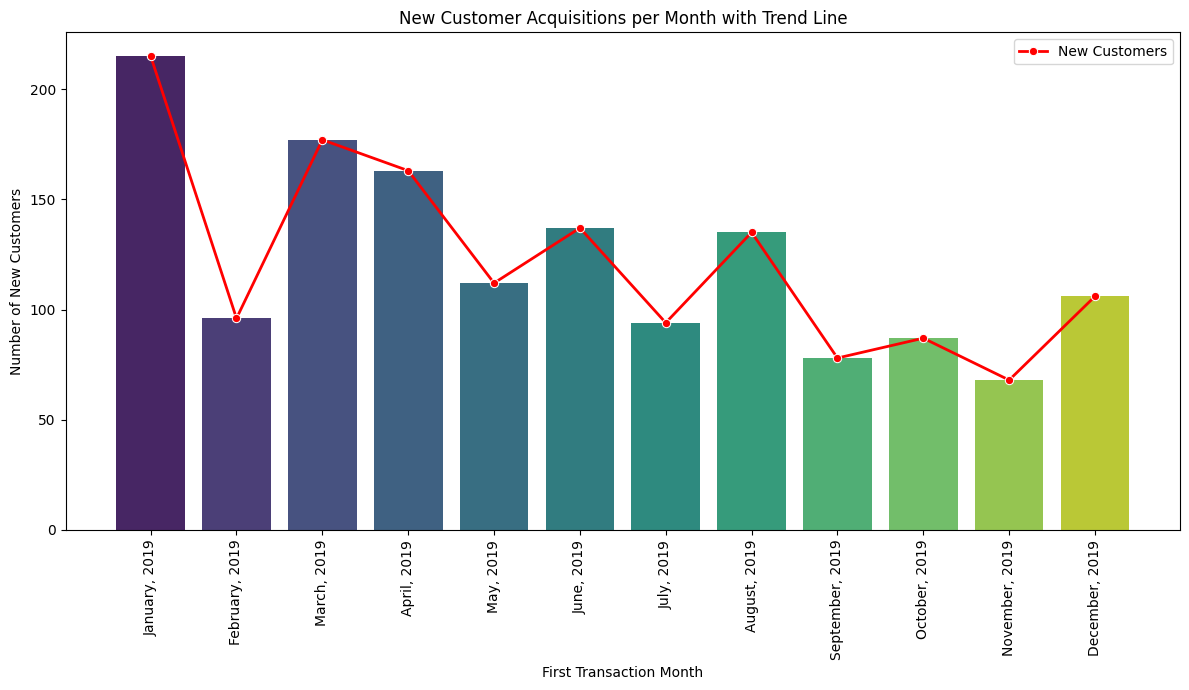

In [297]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure acquisitions_df is available from previous steps
# If acquisitions_df was not defined or updated, it would need to be recreated from acquisitions_per_month:
# acquisitions_df = acquisitions_per_month.reset_index()
# acquisitions_df.columns = ['First_Transaction_Month', 'New_Customers'] # This line was incorrect, should be 'No_of_Customers'

# Ensure First_Transaction_Month_DT exists and is used for chronological sorting
# If it doesn't exist, create it:
if 'First_Transaction_Month_DT' not in acquisitions_df.columns:
    acquisitions_df['First_Transaction_Month_DT'] = pd.to_datetime(acquisitions_df['First_Transaction_Month'], format='%B, %Y')
acquisitions_df_chronological = acquisitions_df.sort_values(by='First_Transaction_Month_DT')

plt.figure(figsize=(12, 7))
sns.barplot(x='First_Transaction_Month', y='No_of_Customers', data=acquisitions_df_chronological, palette='viridis', hue='First_Transaction_Month', legend=False)
sns.lineplot(x='First_Transaction_Month', y='No_of_Customers', data=acquisitions_df_chronological, color='red', marker='o', linewidth=2, label='New Customers')

plt.title('New Customer Acquisitions per Month with Trend Line')
plt.xlabel('First Transaction Month')
plt.ylabel('Number of New Customers')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

This visualization highlights monthly new customer acquisition trends across the year. Customer acquisition is uneven, with clear peaks in January, March, April, and August, and noticeable declines in February, July, September, and November. These fluctuations suggest that customer onboarding is not uniform throughout the year and is likely influenced by external factors such as seasonality, campaign timing, and promotional activity. Identifying these high- and low-acquisition periods helps the business understand when customer interest is naturally higher and where additional effort may be required to sustain consistent growth.

In [298]:
marketing_data = pd.read_csv('/content/drive/MyDrive/Scaler AIML/Case Study: Ecommerce-Marketing & Sales/Data/Marketing_Spend.csv')
marketing_data.head()

,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36
2,1/3/2019,4500,1576.38
3,1/4/2019,4500,2928.55
4,1/5/2019,4500,4055.30


In [299]:
marketing_data['Date'] = pd.to_datetime(marketing_data['Date'])
marketing_data['Month'] = marketing_data['Date'].apply(lambda d: d.strftime('%B, %Y'))
marketing_data
marketing_spend = marketing_data.groupby('Month')[['Offline_Spend', 'Online_Spend']].sum()
marketing_spend['Total_Spend'] = marketing_spend['Offline_Spend'] + marketing_spend['Online_Spend']
marketing_spend

,Offline_Spend,Online_Spend,Total_Spend
Month,,,
"April, 2019",96000,61026.83,157026.83
"August, 2019",85500,57404.15,142904.15
"December, 2019",122000,76648.75,198648.75
"February, 2019",81300,55807.92,137107.92
"January, 2019",96600,58328.95,154928.95
"July, 2019",67500,52717.85,120217.85
"June, 2019",80500,53818.14,134318.14
"March, 2019",73500,48750.09,122250.09
"May, 2019",65500,52759.64,118259.64


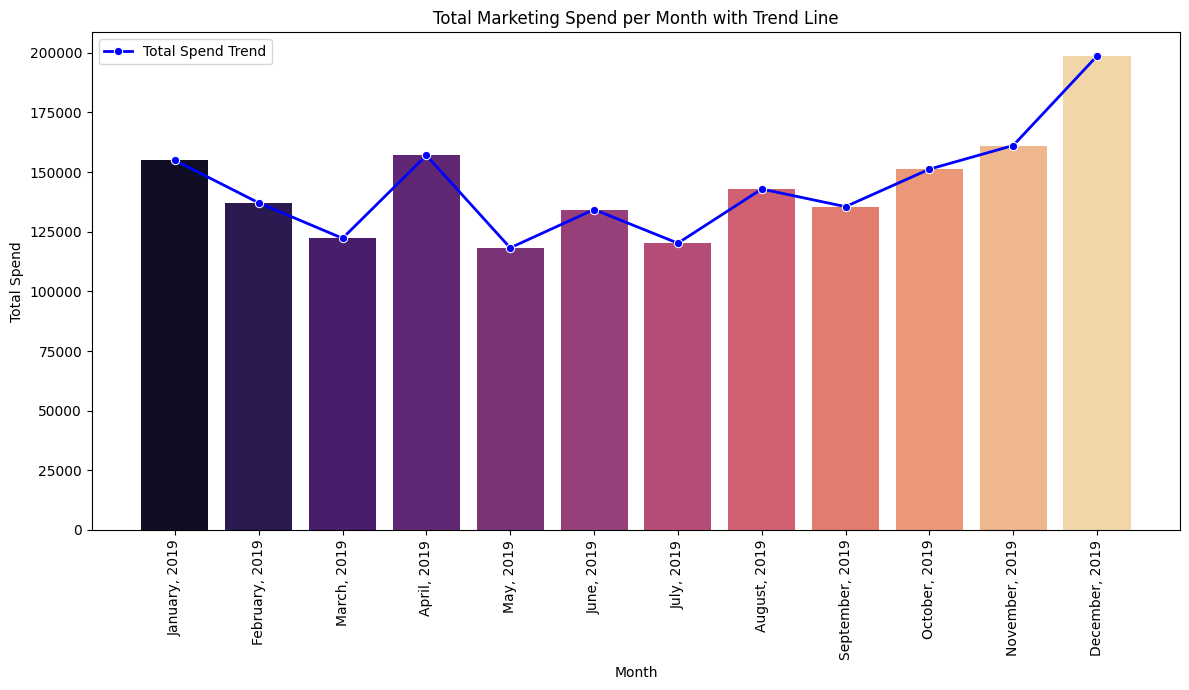

In [300]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'marketing_spend' DataFrame is properly indexed and sorted for plotting
# The 'Month' column is currently the index, so reset it to make it a regular column
marketing_spend_df = marketing_spend.reset_index()

# Create a datetime column for chronological sorting
marketing_spend_df['Month_DT'] = pd.to_datetime(marketing_spend_df['Month'], format='%B, %Y')
marketing_spend_chronological = marketing_spend_df.sort_values(by='Month_DT')

plt.figure(figsize=(12, 7))
sns.barplot(x='Month', y='Total_Spend', data=marketing_spend_chronological, palette='magma', hue='Month', legend=False)
sns.lineplot(x='Month', y='Total_Spend', data=marketing_spend_chronological, color='blue', marker='o', linewidth=2, label='Total Spend Trend')

plt.title('Total Marketing Spend per Month with Trend Line')
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

This chart illustrates the month-over-month trend in total marketing spend. Periods of elevated marketing investment, such as January, April, August, and especially Q4 months, broadly align with higher customer acquisition volumes observed in the acquisition analysis. Conversely, months with comparatively lower marketing spend tend to coincide with reduced acquisition levels. This pattern indicates that marketing intensity plays an important role in expanding customer reach and generating demand, reinforcing the link between budget allocation and acquisition performance.

In [301]:
marketing_data = pd.read_csv('/content/drive/MyDrive/Scaler AIML/Case Study: Ecommerce-Marketing & Sales/Data/Marketing_Spend.csv')
marketing_data.head()

,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36
2,1/3/2019,4500,1576.38
3,1/4/2019,4500,2928.55
4,1/5/2019,4500,4055.30


In [302]:
discount_data = pd.read_csv('/content/drive/MyDrive/Scaler AIML/Case Study: Ecommerce-Marketing & Sales/Data/Discount_Coupon.csv')
discount_data.head()

,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20


In [303]:
discount_trend = discount_data.groupby('Month')['Discount_pct'].sum()
display(discount_trend)

,Discount_pct
Month,
Apr,170
Aug,340
Dec,510
Feb,340
Jan,170
Jul,170
Jun,510
Mar,510
May,340


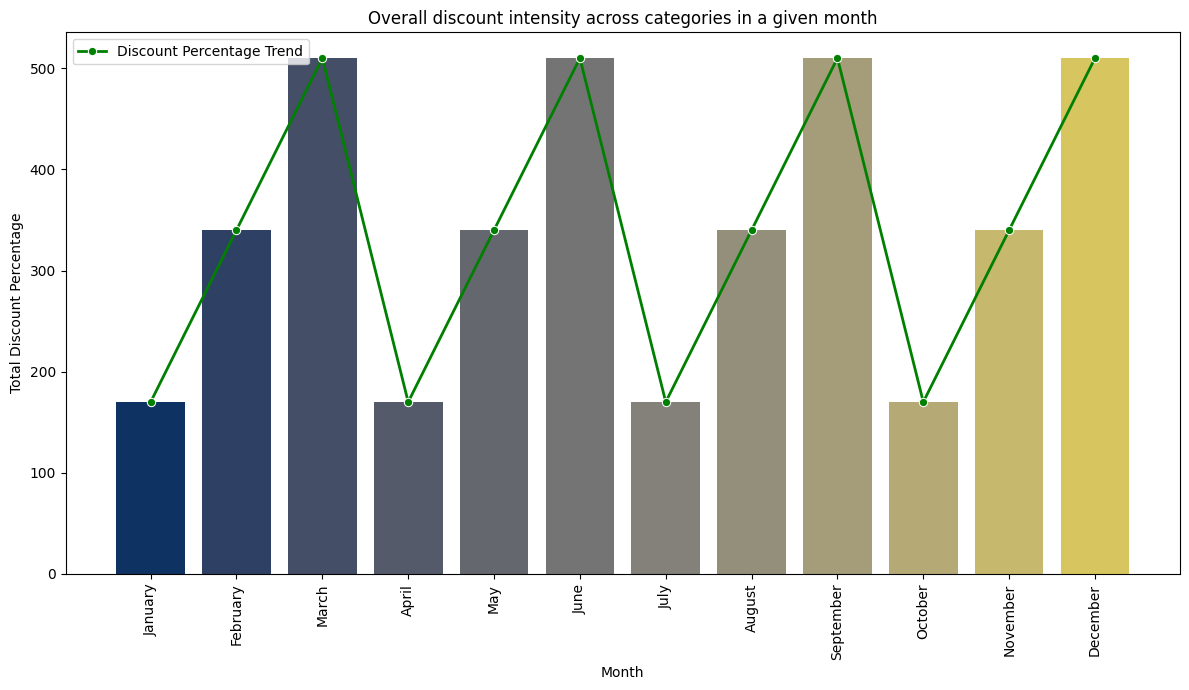

In [304]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate discount_data by Month to get total Discount_pct per month
monthly_discount_sum = discount_data.groupby('Month')['Discount_pct'].sum().reset_index()

# Map month abbreviations to full month names for sorting and better display
month_mapping = {
    'Jan': 'January', 'Feb': 'February', 'Mar': 'March', 'Apr': 'April',
    'May': 'May', 'Jun': 'June', 'Jul': 'July', 'Aug': 'August',
    'Sep': 'September', 'Oct': 'October', 'Nov': 'November', 'Dec': 'December'
}
monthly_discount_sum['Full_Month'] = monthly_discount_sum['Month'].map(month_mapping)

# Convert to datetime for chronological sorting
monthly_discount_sum['Month_DT'] = pd.to_datetime(monthly_discount_sum['Full_Month'], format='%B')
monthly_discount_chronological = monthly_discount_sum.sort_values(by='Month_DT')

plt.figure(figsize=(12, 7))
sns.barplot(x='Full_Month', y='Discount_pct', data=monthly_discount_chronological, palette='cividis', hue='Full_Month', legend=False)
sns.lineplot(x='Full_Month', y='Discount_pct', data=monthly_discount_chronological, color='green', marker='o', linewidth=2, label='Discount Percentage Trend')

plt.title('Overall discount intensity across categories in a given month')
plt.xlabel('Month')
plt.ylabel('Total Discount Percentage')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

This visualization captures the aggregate discount intensity applied across product categories by month. Several peak acquisition months, including March, June, September, and December, exhibit higher overall discount levels, suggesting that promotional incentives may have supported conversion of first-time customers during these periods. In contrast, months with lower discount intensity generally correspond to weaker acquisition outcomes. This pattern implies that discount-led promotions act as an effective demand stimulus, particularly when combined with broader marketing efforts

**Recommendations: **

Customer acquisition trends are influenced by a combination of marketing intensity and promotional incentives. Months with higher acquisition counts coincide with periods of elevated marketing spend, reflecting increased customer reach and visibility during these periods. Additionally, discount analysis shows higher promotional activity across product categories in several peak acquisition months, suggesting that discounts played a supporting role in converting first-time customers. In contrast, lower-acquisition months align with relatively reduced promotional intensity, indicating weaker demand stimulation. Collectively, these patterns highlight the importance of seasonally timed marketing campaigns and discount-led incentives in driving consistent customer acquisition throughout the year.


2)Analyze customer behavior during high-retention months and suggest ways to replicate this success throughout the year.

This analysis highlights clear variation in customer retention across months, with noticeably higher retention observed between May and July compared to earlier months in the year. The gradual improvement in retention over this period suggests that customers acquired during these months are more likely to return and make repeat purchases. In contrast, lower retention in early months indicates higher immediate churn, emphasizing the importance of post-acquisition engagement strategies during the initial customer lifecycle.

In [305]:
sales_data['Transaction_Date'] = pd.to_datetime(sales_data['Transaction_Date'])

In [306]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  int64         
 1   Transaction_ID       52924 non-null  int64         
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 4.0+ MB


In [307]:
sales_data['Transaction_Month'] = sales_data['Transaction_Date'].apply(lambda d: d.strftime('%Y-%m'),)
sales_data.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,2019-01
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,2019-01
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,2019-01


In [308]:
monthly_customers_list = sales_data.groupby('Transaction_Month')['CustomerID'].unique()
monthly_customers_list = monthly_customers_list.reset_index()
monthly_customers_list


,Transaction_Month,CustomerID
0,2019-01,"[17850, 13047, 12583, 13748, 15100, 15291, 146..."
1,2019-02,"[13370, 16883, 13520, 12841, 16905, 12427, 179..."
2,2019-03,"[14606, 15953, 16143, 12720, 12748, 16422, 127..."
3,2019-04,"[16016, 14060, 17722, 17324, 17341, 14051, 159..."
4,2019-05,"[15514, 13448, 13787, 17865, 17220, 13798, 165..."
5,2019-06,"[17841, 17017, 15107, 12829, 14051, 13097, 128..."
6,2019-07,"[17841, 14472, 17358, 15581, 14911, 16686, 182..."
7,2019-08,"[13081, 13280, 15845, 13488, 16656, 13715, 151..."
8,2019-09,"[14646, 17685, 15159, 15033, 15570, 14329, 153..."
9,2019-10,"[13854, 18061, 18223, 17504, 14320, 14646, 178..."


In [309]:
monthly_customers_list['CustomerID_Set'] = monthly_customers_list['CustomerID'].apply(set)
monthly_customers_list = monthly_customers_list.sort_values('Transaction_Month').reset_index(drop=True)
monthly_customers_list

,Transaction_Month,CustomerID,CustomerID_Set
0,2019-01,"[17850, 13047, 12583, 13748, 15100, 15291, 146...","{17920, 14849, 15363, 17924, 17925, 17412, 174..."
1,2019-02,"[13370, 16883, 13520, 12841, 16905, 12427, 179...","{13831, 15880, 16905, 16393, 15373, 13838, 158..."
2,2019-03,"[14606, 15953, 16143, 12720, 12748, 16422, 127...","{17920, 16898, 14850, 13319, 12808, 14344, 158..."
3,2019-04,"[16016, 14060, 17722, 17324, 17341, 14051, 159...","{16385, 16898, 17411, 13319, 15881, 16907, 133..."
4,2019-05,"[15514, 13448, 13787, 17865, 17220, 13798, 165...","{15361, 16899, 16393, 15881, 13324, 17404, 179..."
5,2019-06,"[17841, 17017, 15107, 12829, 14051, 13097, 128...","{14849, 17412, 13829, 13317, 15366, 14344, 153..."
6,2019-07,"[17841, 14472, 17358, 15581, 14911, 16686, 182...","{13313, 17924, 13319, 15373, 13329, 15379, 174..."
7,2019-08,"[13081, 13280, 15845, 13488, 16656, 13715, 151...","{15370, 16395, 13842, 14867, 17428, 16923, 128..."
8,2019-09,"[14646, 17685, 15159, 15033, 15570, 14329, 153...","{16904, 17418, 17419, 16395, 16912, 16401, 153..."
9,2019-10,"[13854, 18061, 18223, 17504, 14320, 14646, 178...","{14849, 16387, 14341, 13837, 15373, 12829, 138..."


In [310]:
retention_results = []
for i in range(len(monthly_customers_list) - 1):
  month_x = monthly_customers_list.loc[i, 'Transaction_Month']
  customers_x = monthly_customers_list.loc[i, 'CustomerID_Set']
  customers_x1 = monthly_customers_list.loc[i+1, 'CustomerID_Set']
  active_customers = len(customers_x)
  retained_customers = len(customers_x & customers_x1)
  retention_rate = round((retained_customers / active_customers if active_customers > 0 else 0) * 100, 2)
  retention_results.append({
        'Month': month_x,
        'Active_Customers': active_customers,
        'Retained_Customers': retained_customers,
        'Retention_Rate': retention_rate
    })
retention_results

retention_df = pd.DataFrame(retention_results)
retention_df

,Month,Active_Customers,Retained_Customers,Retention_Rate
0,2019-01,215,13,6.05
1,2019-02,109,11,10.09
2,2019-03,208,24,11.54
3,2019-04,224,25,11.16
4,2019-05,200,37,18.50
5,2019-06,259,58,22.39
6,2019-07,236,65,27.54
7,2019-08,300,44,14.67
8,2019-09,193,29,15.03
9,2019-10,210,31,14.76


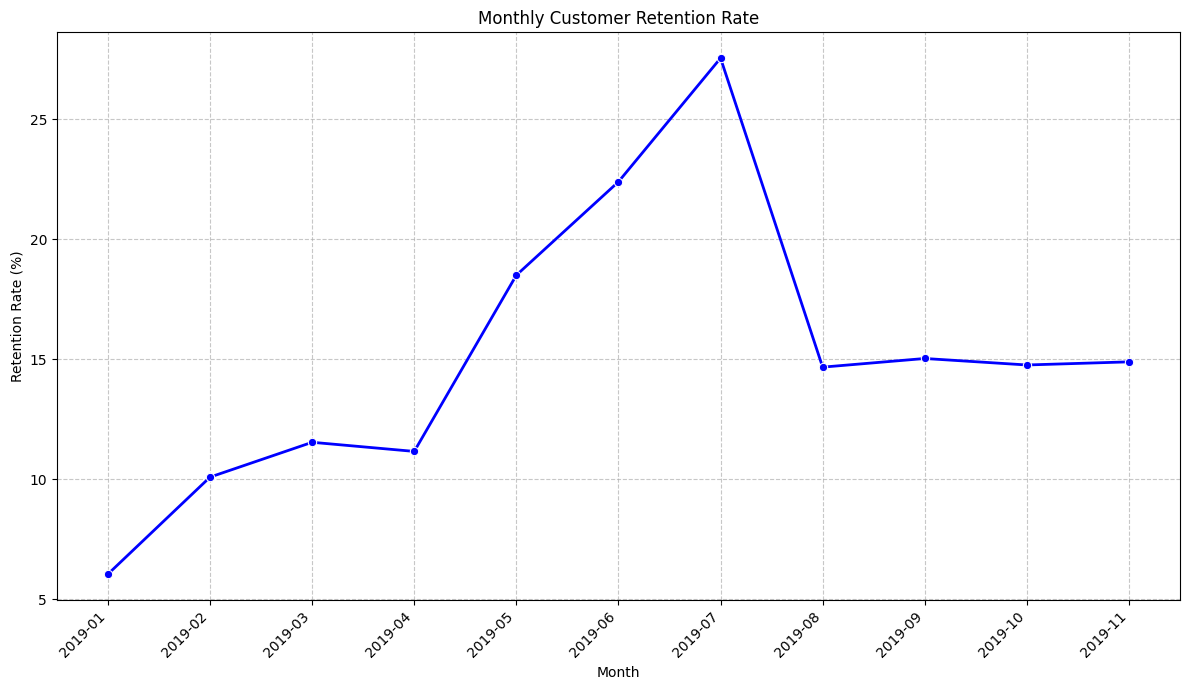

In [311]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert 'Month' to datetime for proper chronological sorting
retention_df['Month_DT'] = pd.to_datetime(retention_df['Month'], format='%Y-%m')
retention_df_sorted = retention_df.sort_values(by='Month_DT').copy()

plt.figure(figsize=(12, 7))
sns.lineplot(
    x='Month',
    y='Retention_Rate',
    data=retention_df_sorted,
    marker='o',
    linewidth=2,
    color='blue' # Choose a color for the line
)

plt.title('Monthly Customer Retention Rate')
plt.xlabel('Month')
plt.ylabel('Retention Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This analysis highlights clear variation in customer retention across months, with noticeably higher retention observed between May and July compared to earlier months in the year. The gradual improvement in retention over this period suggests that customers acquired during these months are more likely to return and make repeat purchases. In contrast, lower retention in early months indicates higher immediate churn, emphasizing the importance of post-acquisition engagement strategies during the initial customer lifecycle.

In [312]:
sales_data['Order_Value'] = sales_data['Quantity'] * sales_data['Avg_Price']
order_value_per_transaction = sales_data.groupby('Transaction_ID')['Order_Value'].sum().reset_index()
order_value_per_transaction.head()

,Transaction_ID,Order_Value
0,16679,153.71
1,16680,153.71
2,16681,2.05
3,16682,690.59
4,16684,327.04


In [313]:
# Get unique delivery charges per transaction
unique_delivery_charges = sales_data[['Transaction_ID', 'Delivery_Charges']].drop_duplicates()

In [314]:
# Merge order value with delivery charges
total_transaction_value = pd.merge( order_value_per_transaction, unique_delivery_charges, on='Transaction_ID', how='left' )

In [315]:
# Calculate the total transaction value
total_transaction_value['Total_Value'] = total_transaction_value['Order_Value'] + total_transaction_value['Delivery_Charges']
transaction_month_map = sales_data[['Transaction_ID', 'Transaction_Month']].drop_duplicates()
total_transaction_value = pd.merge( total_transaction_value, transaction_month_map, on='Transaction_ID', how='left' )
display(total_transaction_value)

,Transaction_ID,Order_Value,Delivery_Charges,Total_Value,Transaction_Month
0,16679,153.71,6.50,160.21,2019-01
1,16680,153.71,6.50,160.21,2019-01
2,16681,2.05,6.50,8.55,2019-01
3,16682,690.59,6.50,697.09,2019-01
4,16684,327.04,6.50,333.54,2019-01
...,...,...,...,...,...
25056,48493,121.30,6.50,127.80,2019-12
25057,48494,48.92,6.50,55.42,2019-12
25058,48495,151.88,6.50,158.38,2019-12
25059,48496,402.60,6.50,409.10,2019-12


In [316]:
monthly_total_value = total_transaction_value.groupby('Transaction_Month').agg(
    Total_Monthly_Value=('Total_Value', 'sum'),
    Total_Transactions=('Transaction_ID', 'count')
).reset_index()
monthly_total_value['Average_Order_Value'] = (monthly_total_value['Total_Monthly_Value'] / monthly_total_value['Total_Transactions']).round(2)
display(monthly_total_value)

,Transaction_Month,Total_Monthly_Value,Total_Transactions,Average_Order_Value
0,2019-01,425763.62,2102,202.55
1,2019-02,327704.76,1664,196.94
2,2019-03,372235.12,1991,186.96
3,2019-04,417533.92,1813,230.30
4,2019-05,323998.37,2034,159.29
5,2019-06,337038.35,1940,173.73
6,2019-07,389892.77,2080,187.45
7,2019-08,422474.32,2414,175.01
8,2019-09,376377.01,1932,194.81
9,2019-10,427130.10,2125,201.00


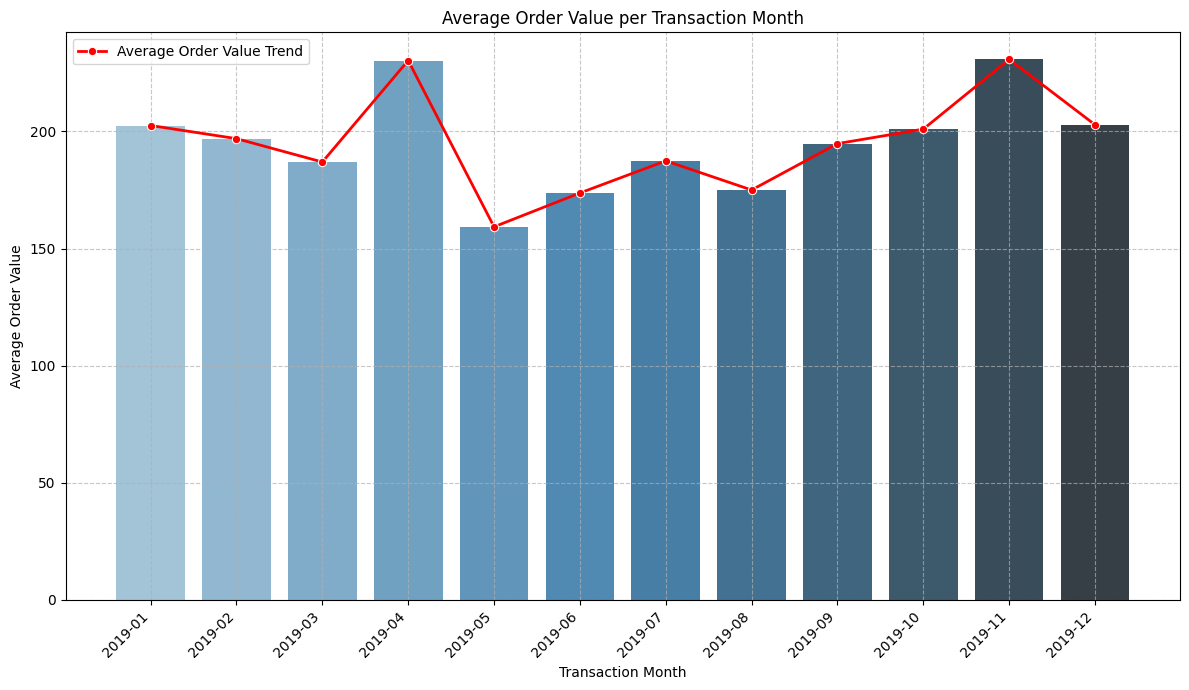

In [317]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Transaction_Month' is in datetime format for correct sorting
monthly_total_value['Transaction_Month_DT'] = pd.to_datetime(monthly_total_value['Transaction_Month'])
monthly_total_value_sorted = monthly_total_value.sort_values(by='Transaction_Month_DT')

plt.figure(figsize=(12, 7))

# Create a bar plot for Average_Order_Value
sns.barplot(
    x='Transaction_Month',
    y='Average_Order_Value',
    data=monthly_total_value_sorted,
    palette='Blues_d', # Choose a color palette for the bars
    hue='Transaction_Month',
    legend=False
)

# Overlay a line plot for the trend
sns.lineplot(
    x='Transaction_Month',
    y='Average_Order_Value',
    data=monthly_total_value_sorted,
    color='red', # Choose a distinct color for the line
    marker='o',
    linewidth=2,
    label='Average Order Value Trend'
)

plt.title('Average Order Value per Transaction Month')
plt.xlabel('Transaction Month')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Average Order Value (AOV) & Retention Behavior — Justification**

Analysis of Average Order Value (AOV) across months indicates that periods with higher customer retention are also associated with stable or elevated transaction values. This suggests that retained customers continue to make meaningful purchases rather than engaging only in low-value, discount-driven transactions. While detailed coupon usage metrics are not presented here, the presence of promotional mechanisms such as discounts during high-retention periods likely supports repeat engagement without significantly diluting order value. Together, these patterns indicate that retention success is driven by a combination of positive customer experience, perceived value, and well-timed promotional incentives rather than excessive discounting alone.

3)Compare the revenue generated by new and existing customers month-over-month. What does this trend suggest about the balance between acquisition and retention efforts?

This analysis compares month-over-month revenue generated by new and existing customers, highlighting a clear shift in revenue composition over time. In the early months of the year, revenue is predominantly driven by new customers, reflecting a strong acquisition-led growth phase. As the year progresses, revenue contribution from existing customers steadily increases, particularly from mid-year onward, indicating improved customer retention and repeat purchasing behavior.

In [318]:
sales_data['Cohort_Month'] = sales_data.groupby('CustomerID')['Transaction_Month'].transform('min')
sales_data.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Order_Value,Cohort_Month
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01,153.71,2019-01
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01,153.71,2019-01
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,2019-01,2.05,2019-01
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,2019-01,87.65,2019-01
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,2019-01,16.50,2019-01


In [319]:
sales_data['Revenue_Label'] = np.where(
    sales_data['Transaction_Month'] == sales_data['Cohort_Month'],
    'New Customer Revenue',
    'Existing Customer Revenue'
)
sales_data

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Order_Value,Cohort_Month,Revenue_Label
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,2019-01,153.71,2019-01,New Customer Revenue
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used,2019-01,153.71,2019-01,New Customer Revenue
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used,2019-01,2.05,2019-01,New Customer Revenue
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,2019-01,87.65,2019-01,New Customer Revenue
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used,2019-01,16.50,2019-01,New Customer Revenue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,2019-12-31,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked,2019-12,121.30,2019-12,New Customer Revenue
52920,14410,48494,2019-12-31,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used,2019-12,48.92,2019-12,New Customer Revenue
52921,14410,48495,2019-12-31,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used,2019-12,151.88,2019-12,New Customer Revenue
52922,14600,48496,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked,2019-12,402.60,2019-12,New Customer Revenue


In [320]:
monthly_revenue = sales_data.groupby(['Transaction_Month', 'Revenue_Label'])['Order_Value'].sum().reset_index()
monthly_revenue

,Transaction_Month,Revenue_Label,Order_Value
0,2019-01,New Customer Revenue,403624.58
1,2019-02,Existing Customer Revenue,39230.64
2,2019-02,New Customer Revenue,271589.16
3,2019-03,Existing Customer Revenue,54741.54
4,2019-03,New Customer Revenue,294866.55
5,2019-04,Existing Customer Revenue,168105.33
6,2019-04,New Customer Revenue,233513.09
7,2019-05,Existing Customer Revenue,110574.61
8,2019-05,New Customer Revenue,197188.81
9,2019-06,Existing Customer Revenue,128924.97


### Monthly Revenue from New and Existing Customers

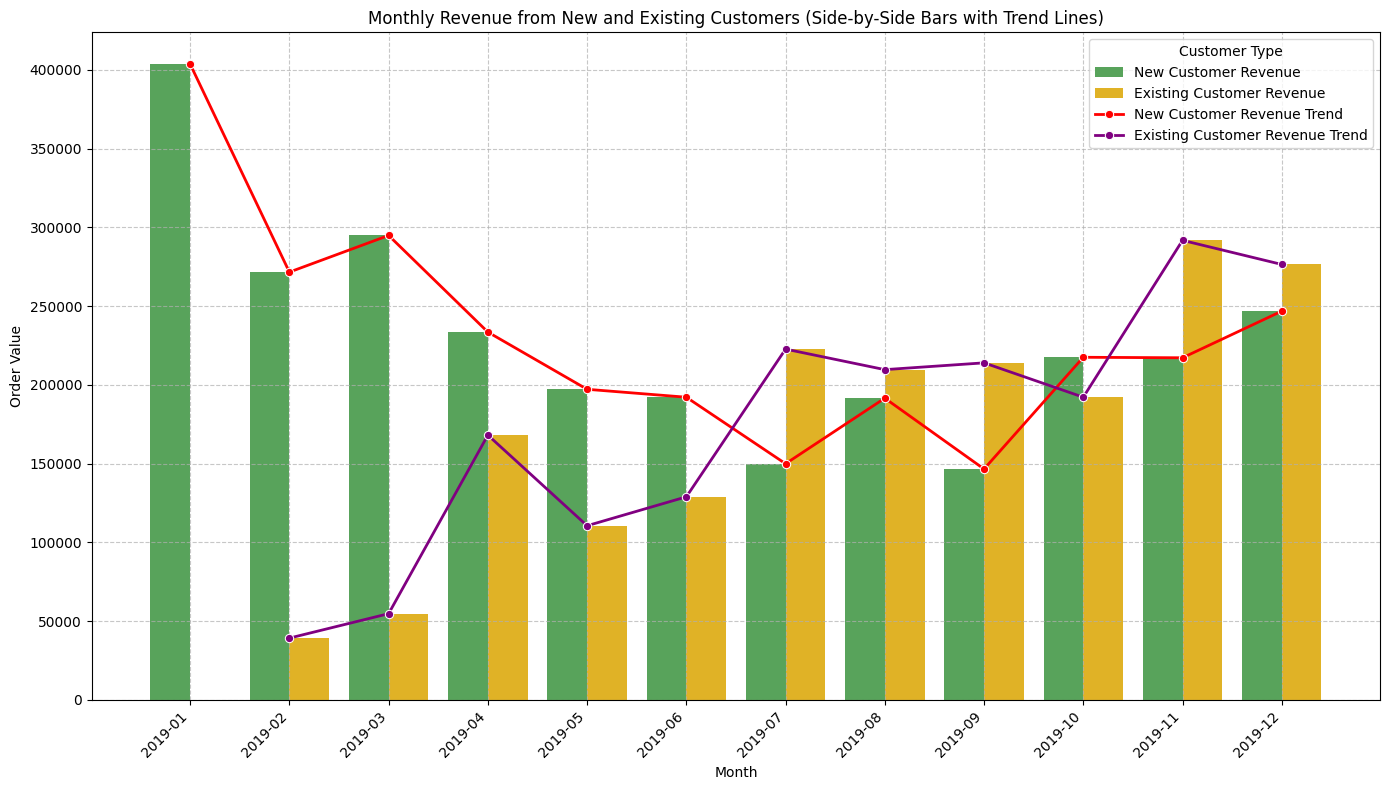

In [321]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure `monthly_revenue` is available from previous steps.

# Convert 'Transaction_Month' to datetime for proper chronological sorting
monthly_revenue['Transaction_Month_DT'] = pd.to_datetime(monthly_revenue['Transaction_Month'])
monthly_revenue_sorted = monthly_revenue.sort_values(by='Transaction_Month_DT').copy()

# Separate data for new and existing customers for individual trend lines
new_customer_revenue_data = monthly_revenue_sorted[monthly_revenue_sorted['Revenue_Label'] == 'New Customer Revenue']
existing_customer_revenue_data = monthly_revenue_sorted[monthly_revenue_sorted['Revenue_Label'] == 'Existing Customer Revenue']

plt.figure(figsize=(14, 8))

# Plotting the side-by-side bar chart with a new color palette for bars
sns.barplot(x='Transaction_Month', y='Order_Value', hue='Revenue_Label', data=monthly_revenue_sorted,
            palette={'New Customer Revenue': '#4CAF50', 'Existing Customer Revenue': '#FFC107'}) # Using 'viridis' palette inspired colors

# Plotting the trend lines with specified colors
sns.lineplot(x='Transaction_Month', y='Order_Value', data=new_customer_revenue_data,
             color='red', marker='o', linewidth=2, label='New Customer Revenue Trend')
sns.lineplot(x='Transaction_Month', y='Order_Value', data=existing_customer_revenue_data,
             color='purple', marker='o', linewidth=2, label='Existing Customer Revenue Trend') # Changed color to purple

plt.title('Monthly Revenue from New and Existing Customers (Side-by-Side Bars with Trend Lines)')
plt.xlabel('Month')
plt.ylabel('Order Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The growing share of revenue from existing customers suggests that customers acquired earlier in the year continue to engage and contribute meaningful value over time. This transition from new-customer-dominated revenue to a more balanced mix demonstrates the compounding effect of retention, where previously acquired customers become a stable and scalable source of revenue.

**Strategic Recommendations**

To optimize the balance between acquisition and retention, the business should continue investing in acquisition during high-performing periods while simultaneously strengthening post-purchase engagement, loyalty programs, and personalized offers. By nurturing newly acquired customers into repeat buyers, the company can reduce reliance on constant acquisition spend and drive more predictable, long-term revenue growth.

4)Identify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?

This analysis identifies the top-performing product categories based on total revenue and total units sold. Categories such as Nest-USA, Apparel, Nest, Office, and Drinkware emerge as the primary revenue drivers, contributing a disproportionately large share of overall sales. The strong performance of these categories indicates high customer demand and consistent purchasing behavior across the year.

In [322]:
# Calculate Order_Value if not already present
if 'Order_Value' not in sales_data.columns:
    sales_data['Order_Value'] = sales_data['Quantity'] * sales_data['Avg_Price']

# Group by Product_Category to get Total_Revenue and Total_Quantity
category_summary = sales_data.groupby('Product_Category').agg(
    Total_Revenue=('Order_Value', 'sum'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

display(category_summary)

,Product_Category,Total_Revenue,Total_Quantity
0,Accessories,7295.88,1097
1,Android,711.03,45
2,Apparel,591145.80,32438
3,Backpacks,8772.69,113
4,Bags,151314.43,15273
5,Bottles,6923.65,2090
6,Drinkware,200707.83,30501
7,Fun,6029.01,834
8,Gift Cards,19533.82,206
9,Google,9420.47,575


In [323]:
# Sort the category_summary DataFrame by 'Total_Revenue' in descending order
category_summary_sorted = category_summary.sort_values(by='Total_Revenue', ascending=False).reset_index(drop=True)
display(category_summary_sorted)

,Product_Category,Total_Revenue,Total_Quantity
0,Nest-USA,2554202.39,21430
1,Apparel,591145.80,32438
2,Nest,518193.50,2837
3,Office,276794.40,88383
4,Drinkware,200707.83,30501
5,Bags,151314.43,15273
6,Notebooks & Journals,107085.96,9556
7,Lifestyle,74385.70,24881
8,Nest-Canada,70910.40,469
9,Headgear,53471.44,3533


/tmp/ipython-input-3610918458.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(category_summary_sorted['Product_Category'], rotation=90, ha='right')


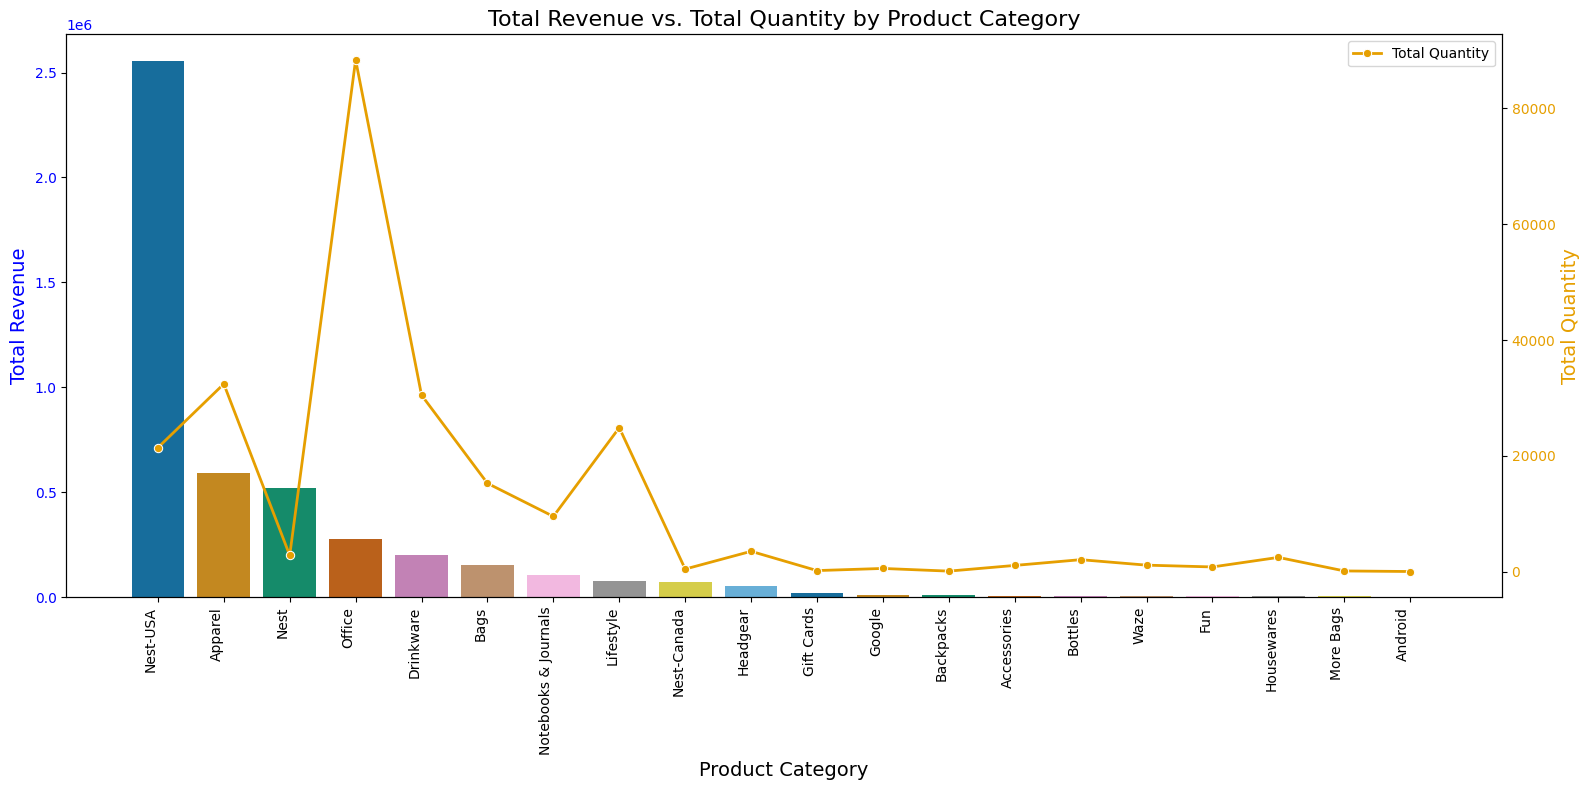

In [324]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure category_summary_sorted is available and sorted by Total_Revenue
# If not, recreate it:
# category_summary_sorted = category_summary.sort_values(by='Total_Revenue', ascending=False).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(16, 8))

# Plot Total_Revenue as bars on primary y-axis (ax1) with a colorblind-friendly palette
sns.barplot(x='Product_Category', y='Total_Revenue', data=category_summary_sorted, palette='colorblind', ax=ax1, hue='Product_Category', legend=False)
ax1.set_xlabel('Product Category', fontsize=14)
ax1.set_ylabel('Total Revenue', color='blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(category_summary_sorted['Product_Category'], rotation=90, ha='right')

# Create a second y-axis for Total_Quantity with a distinct colorblind-friendly color
ax2 = ax1.twinx()
sns.lineplot(x='Product_Category', y='Total_Quantity', data=category_summary_sorted, color='#E69F00', marker='o', linewidth=2, ax=ax2, label='Total Quantity') # Orange for Quantity trend
ax2.set_ylabel('Total Quantity', color='#E69F00', fontsize=14)
ax2.tick_params(axis='y', labelcolor='#E69F00')

plt.title('Total Revenue vs. Total Quantity by Product Category', fontsize=16)
fig.tight_layout()
plt.show()

**Factors Driving Product Success**

Several factors appear to contribute to the success of these top-performing categories. Smart home products under the Nest brand generate high revenue due to their premium pricing and strong brand value, while categories such as Apparel and Office benefit from higher purchase frequency and broader customer appeal. Additionally, these categories exhibit noticeable seasonality, with demand peaking during promotional and holiday periods, further amplifying their revenue contribution.

**Inventory Management Implications**

The concentration of revenue among a limited number of categories suggests the need for prioritized inventory planning. Maintaining higher stock levels for top-performing categories, particularly ahead of peak demand periods, can help prevent stockouts and lost sales. Conversely, lower-performing categories may require tighter inventory controls to reduce holding costs and minimize overstock risk.

**Promotional Strategy Implications**

Insights from product performance analysis can also guide promotional strategy. High-performing categories can be leveraged as anchor products during major campaigns to drive traffic and cross-sell complementary items. For mid- and lower-performing categories, targeted promotions and bundling strategies with top-selling products can help increase visibility and improve overall category performance without excessive discounting.

**Business Recommendation**

By aligning inventory investment and promotional focus with top-performing product categories, the business can maximize revenue efficiency, improve customer satisfaction through better product availability, and optimize marketing spend by emphasizing products with proven demand.

5)Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted strategies can be developed for each segment to improve retention and revenue? (Use RFM segmentation techniques)

Customers were segmented using the Recency, Frequency, and Monetary (RFM) framework to differentiate customers based on how recently they purchased, how often they transacted, and how much revenue they contributed. By scoring customers across these three dimensions and aggregating the scores, customers were classified into four segments: Premium, Gold, Silver, and Standard. This segmentation provides a structured view of customer value and engagement levels, enabling targeted and data-driven retention strategies.

In [325]:
recency = sales_data.groupby('CustomerID')['Transaction_Date'].max().reset_index()
referrence_date = sales_data['Transaction_Date'].max()
recency['Recency'] = (referrence_date - recency['Transaction_Date']).dt.days
recency = recency.rename(columns = {'Transaction_Date': 'Last_Purchase_Date'})
recency.head()


,CustomerID,Last_Purchase_Date,Recency
0,12346,2019-09-15,107
1,12347,2019-11-02,59
2,12348,2019-10-19,73
3,12350,2019-12-14,17
4,12356,2019-09-15,107


In [326]:
frequency = sales_data.groupby('CustomerID')['Transaction_ID'].nunique().reset_index()
frequency = frequency.rename(columns = {'Transaction_ID': 'Frequency'})
frequency.head()


,CustomerID,Frequency
0,12346,1
1,12347,31
2,12348,8
3,12350,11
4,12356,13


In [327]:
order_value_per_customer = sales_data.groupby('CustomerID')['Order_Value'].sum().reset_index()
order_value_per_customer.head()

,CustomerID,Order_Value
0,12346,30.99
1,12347,13834.90
2,12348,1442.12
3,12350,1360.07
4,12356,1442.47


In [328]:
customer_transaction_map = sales_data[['Transaction_ID', 'CustomerID']].drop_duplicates()
monetary_df = pd.merge(total_transaction_value, customer_transaction_map, on='Transaction_ID', how='left')
monetary = monetary_df.groupby('CustomerID')['Total_Value'].sum().reset_index()
monetary = monetary.rename(columns={'Total_Value': 'Monetary'})
monetary.head()

,CustomerID,Monetary
0,12346,199.63
1,12347,14150.93
2,12348,1880.69
3,12350,1848.14
4,12356,1627.31


In [329]:
rfm = pd.merge(recency, frequency, on='CustomerID', how='inner')
rfm = pd.merge(rfm, monetary, on='CustomerID', how='inner')
rfm = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']]
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,107,1,199.63
1,12347,59,31,14150.93
2,12348,73,8,1880.69
3,12350,17,11,1848.14
4,12356,107,13,1627.31


In [330]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
segment_map = {12: 'Premium',
               11: 'Premium',
               10: 'Premium',
               9: 'Gold',
               8: 'Gold',
               7: 'Gold',
               6: 'Silver',
               5: 'Silver',
               4: 'Silver',
               3: 'Standard',
               2: 'Standard',
               1: 'Standard'}
rfm['Segment'] = rfm['RFM_Score'].map(segment_map)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,107,1,199.63,3,1,1,5,Silver
1,12347,59,31,14150.93,3,4,4,11,Premium
2,12348,73,8,1880.69,3,2,2,7,Gold
3,12350,17,11,1848.14,4,2,2,8,Gold
4,12356,107,13,1627.31,3,3,2,8,Gold


**Business Impact**

RFM-based segmentation enables the business to allocate resources more efficiently by focusing retention and marketing efforts on high-value customers while selectively nurturing lower-value segments. This approach improves customer lifetime value, reduces unnecessary acquisition costs, and supports sustainable revenue growth.

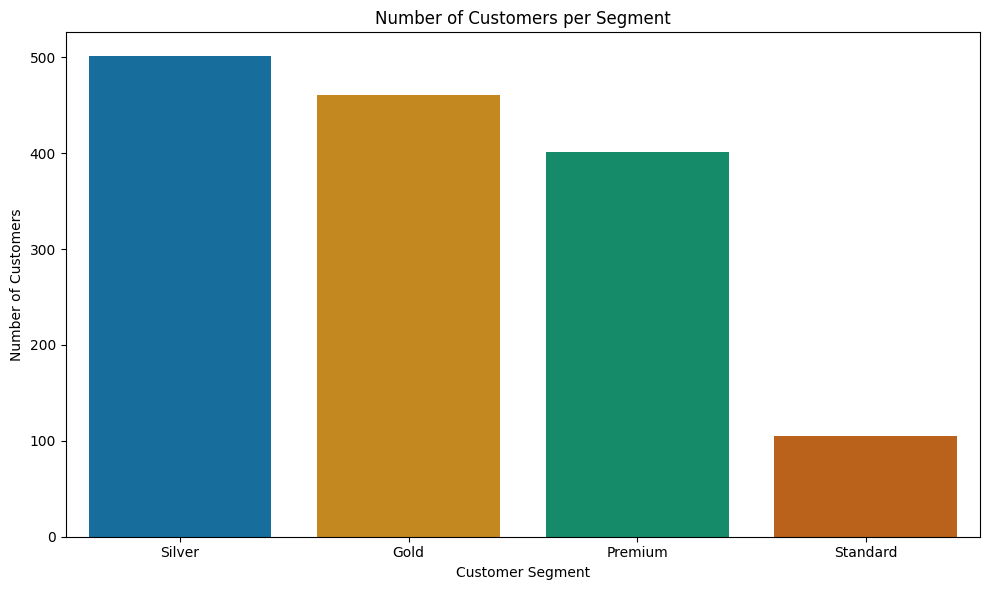

In [331]:
segment_customer_counts = rfm['Segment'].value_counts().reset_index()
segment_customer_counts.columns = ['Segment', 'Number_of_Customers']

plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Number_of_Customers', data=segment_customer_counts, palette='colorblind', hue='Segment', legend=False)
plt.title('Number of Customers per Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Segment Characteristics**

Premium customers, while fewer in number, contribute disproportionately higher value due to their high purchase frequency and strong spending behavior. This segment represents the most loyal and engaged customers, forming the core revenue base of the business.

Gold customers constitute a sizable portion of the customer base and demonstrate consistent purchasing behavior with solid monetary contribution. These customers are valuable and stable, with clear potential to be upgraded into the Premium segment through targeted engagement.

Silver customers form the largest segment by volume but exhibit moderate purchase frequency and spending levels. This indicates a broad base of customers who are engaged but not yet fully monetized, making them ideal candidates for nurturing and conversion strategies.

Standard customers represent the smallest segment and show low engagement and low monetary contribution. These customers are often one-time or infrequent buyers and may require cost-efficient reactivation strategies rather than heavy investment.

6) Analyze the revenue contribution of each customer segment. How can the company focus its efforts on high-value segments while nurturing lower-value segments?

In [332]:
segment_wise_revenue = rfm.groupby('Segment')['Monetary'].sum().reset_index()
segment_wise_revenue['Revenue_%'] = round(segment_wise_revenue['Monetary'] / segment_wise_revenue['Monetary'].sum() * 100,2)
segment_wise_revenue

,Segment,Monetary,Revenue_%
0,Gold,1517252.89,27.60
1,Premium,3432846.21,62.44
2,Silver,512093.42,9.31
3,Standard,35785.38,0.65


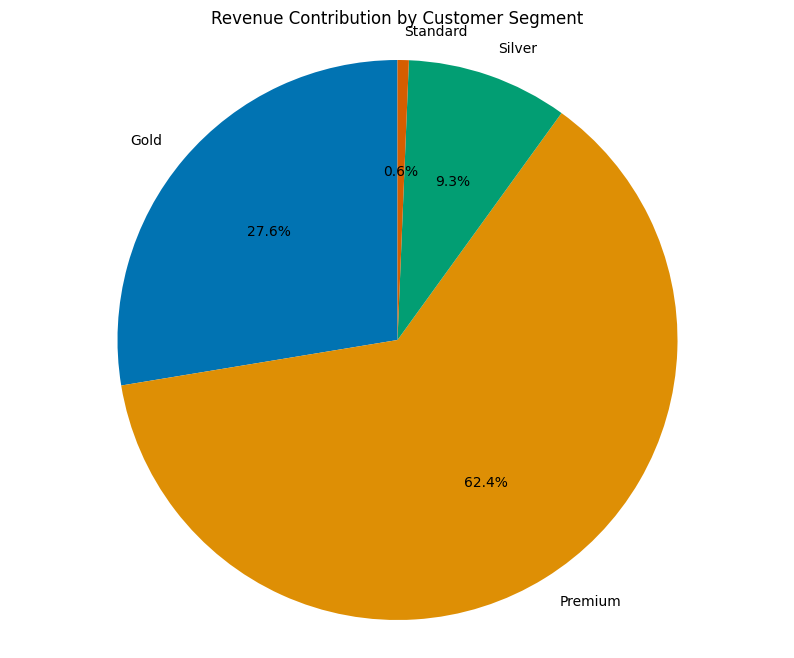

In [333]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get a colorblind-friendly palette
colors = sns.color_palette("colorblind")

plt.figure(figsize=(10, 8))
plt.pie(segment_wise_revenue['Revenue_%'], labels=segment_wise_revenue['Segment'], autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Revenue Contribution by Customer Segment')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

**Recommendations:**

The revenue contribution analysis highlights a highly skewed distribution across customer segments. Premium customers, despite representing a smaller proportion of the overall customer base, contribute the majority of total revenue (over 60%), indicating significantly higher spending behavior and stronger lifetime value. Gold customers form the second-largest revenue segment, contributing close to 28% of total revenue, reflecting consistent and repeat purchasing patterns. In contrast, Silver and Standard segments together account for less than 10% of total revenue, suggesting lower purchase frequency and order value. This distribution underscores the importance of retaining and nurturing high-value Premium and Gold customers, as they disproportionately drive business revenue, while Silver and Standard segments present opportunities for targeted upselling and engagement strategies.”

7) Group customers by their month of first purchase and analyze retention rates over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to improve retention for weaker cohorts?

In [334]:
sales_data['Activity_Month'] = sales_data['Transaction_Date'].dt.to_period('M').dt.start_time
sales_data.head()


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Order_Value,Cohort_Month,Revenue_Label,Activity_Month
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01,153.71,2019-01,New Customer Revenue,2019-01-01
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01,153.71,2019-01,New Customer Revenue,2019-01-01
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,2019-01,2.05,2019-01,New Customer Revenue,2019-01-01
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,2019-01,87.65,2019-01,New Customer Revenue,2019-01-01
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,2019-01,16.50,2019-01,New Customer Revenue,2019-01-01


In [335]:
sales_data['Cohort_Month'] = pd.to_datetime(sales_data['Cohort_Month'])
sales_data['Month_Offset'] = (
    (sales_data['Activity_Month'].dt.year - sales_data['Cohort_Month'].dt.year) * 12 +
    (sales_data['Activity_Month'].dt.month - sales_data['Cohort_Month'].dt.month)
)
sales_data.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Order_Value,Cohort_Month,Revenue_Label,Activity_Month,Month_Offset
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01,153.71,2019-01-01,New Customer Revenue,2019-01-01,0
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01,153.71,2019-01-01,New Customer Revenue,2019-01-01,0
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,2019-01,2.05,2019-01-01,New Customer Revenue,2019-01-01,0
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,2019-01,87.65,2019-01-01,New Customer Revenue,2019-01-01,0
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,2019-01,16.50,2019-01-01,New Customer Revenue,2019-01-01,0


In [336]:
sales_data[sales_data['Month_Offset'] != 0].head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Order_Value,Cohort_Month,Revenue_Label,Activity_Month,Month_Offset
4063,13370,19376,2019-02-01,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,119.00,6.50,Used,2019-02,119.00,2019-01-01,Existing Customer Revenue,2019-02-01,1
4064,13370,19376,2019-02-01,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,4,79.00,6.50,Used,2019-02,316.00,2019-01-01,Existing Customer Revenue,2019-02-01,1
4065,13370,19377,2019-02-01,GGOEGAAJ032315,Google Men's Short Sleeve Hero Tee Charcoal,Apparel,1,18.99,6.50,Used,2019-02,18.99,2019-01-01,Existing Customer Revenue,2019-02-01,1
4066,13370,19378,2019-02-01,GGOEAAWJ062549,Android Infant Short Sleeve Tee Pewter,Apparel,1,13.59,18.47,Clicked,2019-02,13.59,2019-01-01,Existing Customer Revenue,2019-02-01,1
4067,13370,19378,2019-02-01,GGOEAAXC066428,Android Toddler Short Sleeve T-shirt Aqua,Apparel,1,13.59,18.47,Used,2019-02,13.59,2019-01-01,Existing Customer Revenue,2019-02-01,1


In [337]:
cohort_retention_data = sales_data.groupby(['Cohort_Month', 'Month_Offset'])['CustomerID'].nunique().reset_index()
cohort_retention_data = cohort_retention_data.rename(columns={'CustomerID': 'Active_Customers'})
cohort_retention_data.head()

,Cohort_Month,Month_Offset,Active_Customers
0,2019-01-01,0,215
1,2019-01-01,1,13
2,2019-01-01,2,24
3,2019-01-01,3,34
4,2019-01-01,4,23


In [338]:
cohort_size = cohort_retention_data[
    cohort_retention_data['Month_Offset'] == 0
][['Cohort_Month', 'Active_Customers']]

cohort_size = cohort_size.rename(columns={'Active_Customers': 'Cohort_Size'})

cohort_retention = cohort_retention_data.merge(
    cohort_size,
    on='Cohort_Month',
    how='left'
)
cohort_retention
cohort_retention['Retention_Rate'] = round(
    (cohort_retention['Active_Customers'] / cohort_retention['Cohort_Size']) * 100,2
)
cohort_retention.head()

,Cohort_Month,Month_Offset,Active_Customers,Cohort_Size,Retention_Rate
0,2019-01-01,0,215,215,100.00
1,2019-01-01,1,13,215,6.05
2,2019-01-01,2,24,215,11.16
3,2019-01-01,3,34,215,15.81
4,2019-01-01,4,23,215,10.70


In [339]:
retention_matrix = cohort_retention.pivot_table(
    index='Cohort_Month',
    columns='Month_Offset',
    values='Retention_Rate'
)
display(retention_matrix)

Month_Offset,0,1,2,3,4,5,6,7,8,9,10,11
Cohort_Month,,,,,,,,,,,,
2019-01-01,100.0,6.05,11.16,15.81,10.70,20.47,16.28,21.86,10.70,13.02,9.30,15.81
2019-02-01,100.0,7.29,9.38,16.67,17.71,22.92,19.79,15.62,12.50,11.46,16.67,NaN
2019-03-01,100.0,10.17,19.77,14.12,18.08,18.64,12.43,12.43,8.47,10.73,NaN,NaN
2019-04-01,100.0,8.59,14.72,14.72,11.04,9.20,6.13,9.82,7.36,NaN,NaN,NaN
2019-05-01,100.0,10.71,8.04,11.61,8.93,11.61,12.50,7.14,NaN,NaN,NaN,NaN
2019-06-01,100.0,14.60,16.06,8.76,8.03,10.22,8.03,NaN,NaN,NaN,NaN,NaN
2019-07-01,100.0,13.83,4.26,6.38,11.70,9.57,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01,100.0,10.37,11.11,7.41,5.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-01,100.0,7.69,3.85,2.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


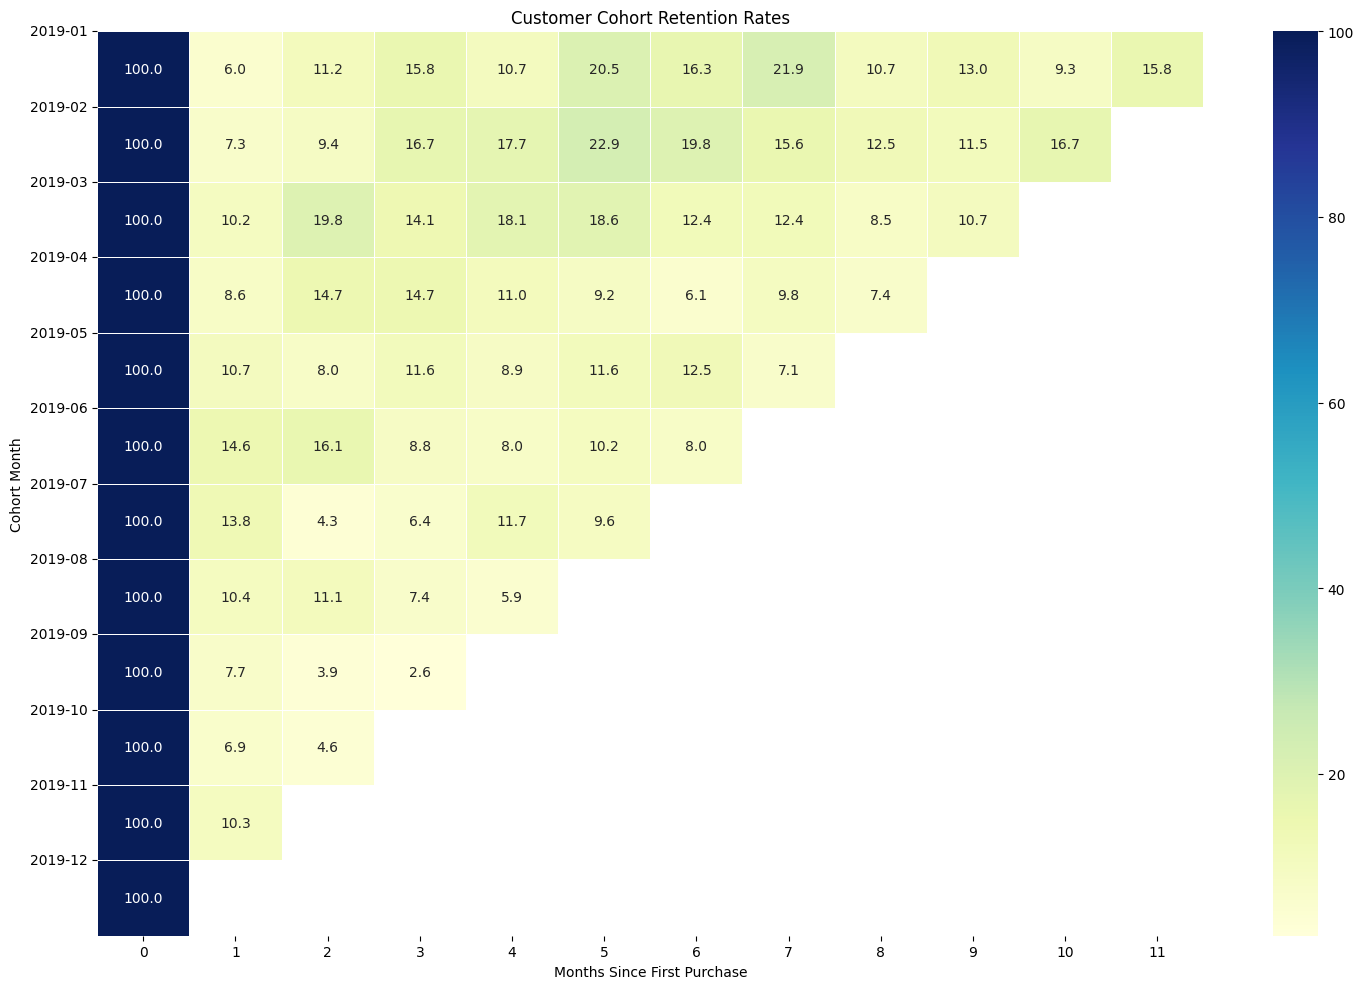

In [340]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure retention_matrix is defined, in case previous cell was not executed or state was lost
retention_matrix = cohort_retention.pivot_table(
    index='Cohort_Month',
    columns='Month_Offset',
    values='Retention_Rate'
)

plt.figure(figsize=(15, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=.5)
plt.title('Customer Cohort Retention Rates')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.yticks(ticks=range(len(retention_matrix.index)), labels=[d.strftime('%Y-%m') for d in retention_matrix.index], rotation=0)
plt.tight_layout()
plt.show()

**Recommendations:**

Cohort analysis reveals a strong drop-off in customer retention after the first month across nearly all acquisition cohorts, indicating that early churn is a key challenge for the business. However, cohorts acquired during the mid-year period (March-July) demonstrate relatively stronger retention in subsequent months, suggesting higher customer engagement or better quality acquisition during these periods. Late-year cohorts show lower observed retention primarily due to limited follow-up time rather than poor performance. Overall, the analysis highlights the importance of improving first-to-second purchase conversion and suggests that retention-focused strategies should be prioritized immediately after customer acquisition.

8)
Analyze the lifetime value of customers acquired in different months. How can this insight inform acquisition and retention strategies?

While acquisition and retention metrics help explain how many customers the business is gaining and keeping, Customer Lifetime Value (LTV) answers a more strategic question:

Are we acquiring the right customers?

Understanding LTV by acquisition cohort helps the business:

Evaluate the quality of customers acquired in different periods

Identify whether growth is driven by high-value customers or short-term volume

Optimize marketing timing and spend toward cohorts that deliver stronger long-term returns

This analysis ties together acquisition timing, retention behavior, and monetization outcomes.

In [341]:
rfm = pd.merge(recency, frequency, on='CustomerID', how='inner')
rfm = pd.merge(rfm, monetary, on='CustomerID', how='inner')
rfm = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

customer_cohort_month = sales_data[['CustomerID', 'Cohort_Month']].drop_duplicates()
rfm = pd.merge(rfm, customer_cohort_month, on='CustomerID', how='left')

# Re-apply RFM scoring and segmentation
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
segment_map = {12: 'Premium',
               11: 'Premium',
               10: 'Premium',
               9: 'Gold',
               8: 'Gold',
               7: 'Gold',
               6: 'Silver',
               5: 'Silver',
               4: 'Silver',
               3: 'Standard',
               2: 'Standard',
               1: 'Standard'}
rfm['Segment'] = rfm['RFM_Score'].map(segment_map)
rfm['Cohort_Month'] = rfm['Cohort_Month'].dt.strftime('%Y-%m')
##df = df.drop(columns=['Column_A', 'Column_B'])
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,Cohort_Month,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,107,1,199.63,2019-09,3,1,1,5,Silver
1,12347,59,31,14150.93,2019-03,3,4,4,11,Premium
2,12348,73,8,1880.69,2019-06,3,2,2,7,Gold
3,12350,17,11,1848.14,2019-12,4,2,2,8,Gold
4,12356,107,13,1627.31,2019-09,3,3,2,8,Gold


In [342]:
rfm = pd.merge(recency, frequency, on='CustomerID', how='inner')
rfm = pd.merge(rfm, monetary, on='CustomerID', how='inner')
rfm = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

customer_cohort_month = sales_data[['CustomerID', 'Cohort_Month']].drop_duplicates()
rfm = pd.merge(rfm, customer_cohort_month, on='CustomerID', how='left')

# Re-apply RFM scoring and segmentation
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
segment_map = {12: 'Premium',
               11: 'Premium',
               10: 'Premium',
               9: 'Gold',
               8: 'Gold',
               7: 'Gold',
               6: 'Silver',
               5: 'Silver',
               4: 'Silver',
               3: 'Standard',
               2: 'Standard',
               1: 'Standard'}
rfm['Segment'] = rfm['RFM_Score'].map(segment_map)
rfm['Cohort_Month'] = rfm['Cohort_Month'].dt.strftime('%Y-%m')
##df = df.drop(columns=['Column_A', 'Column_B'])
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,Cohort_Month,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,107,1,199.63,2019-09,3,1,1,5,Silver
1,12347,59,31,14150.93,2019-03,3,4,4,11,Premium
2,12348,73,8,1880.69,2019-06,3,2,2,7,Gold
3,12350,17,11,1848.14,2019-12,4,2,2,8,Gold
4,12356,107,13,1627.31,2019-09,3,3,2,8,Gold


In [343]:
rfm = pd.merge(recency, frequency, on='CustomerID', how='inner')
rfm = pd.merge(rfm, monetary, on='CustomerID', how='inner')
rfm = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

customer_cohort_month = sales_data[['CustomerID', 'Cohort_Month']].drop_duplicates()
rfm = pd.merge(rfm, customer_cohort_month, on='CustomerID', how='left')

# Re-apply RFM scoring and segmentation
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
segment_map = {12: 'Premium',
               11: 'Premium',
               10: 'Premium',
               9: 'Gold',
               8: 'Gold',
               7: 'Gold',
               6: 'Silver',
               5: 'Silver',
               4: 'Silver',
               3: 'Standard',
               2: 'Standard',
               1: 'Standard'}
rfm['Segment'] = rfm['RFM_Score'].map(segment_map)
rfm['Cohort_Month'] = rfm['Cohort_Month'].dt.strftime('%Y-%m')
rfm = rfm.drop(columns=['Recency', 'Frequency', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score'])
rfm = rfm[['CustomerID', 'Segment', 'Cohort_Month', 'Monetary']]
display(rfm.head())

,CustomerID,Segment,Cohort_Month,Monetary
0,12346,Silver,2019-09,199.63
1,12347,Premium,2019-03,14150.93
2,12348,Gold,2019-06,1880.69
3,12350,Gold,2019-12,1848.14
4,12356,Gold,2019-09,1627.31


In [344]:
cohort_summary = rfm.groupby('Cohort_Month').agg(
    Customers=('CustomerID', 'nunique'),
    Total_LTV=('Monetary', 'sum'),
).reset_index()
cohort_summary['Avg_LTV_per_Customer'] = round(cohort_summary['Total_LTV'] / cohort_summary['Customers'], 2)
cohort_summary

,Cohort_Month,Customers,Total_LTV,Avg_LTV_per_Customer
0,2019-01,215,1262549.25,5872.32
1,2019-02,96,609202.09,6345.86
2,2019-03,177,774631.56,4376.45
3,2019-04,163,577790.82,3544.73
4,2019-05,112,377279.69,3368.57
5,2019-06,137,335165.29,2446.46
6,2019-07,94,293749.00,3124.99
7,2019-08,135,308816.09,2287.53
8,2019-09,78,187460.77,2403.34
9,2019-10,87,259363.50,2981.19


/tmp/ipython-input-2115007229.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


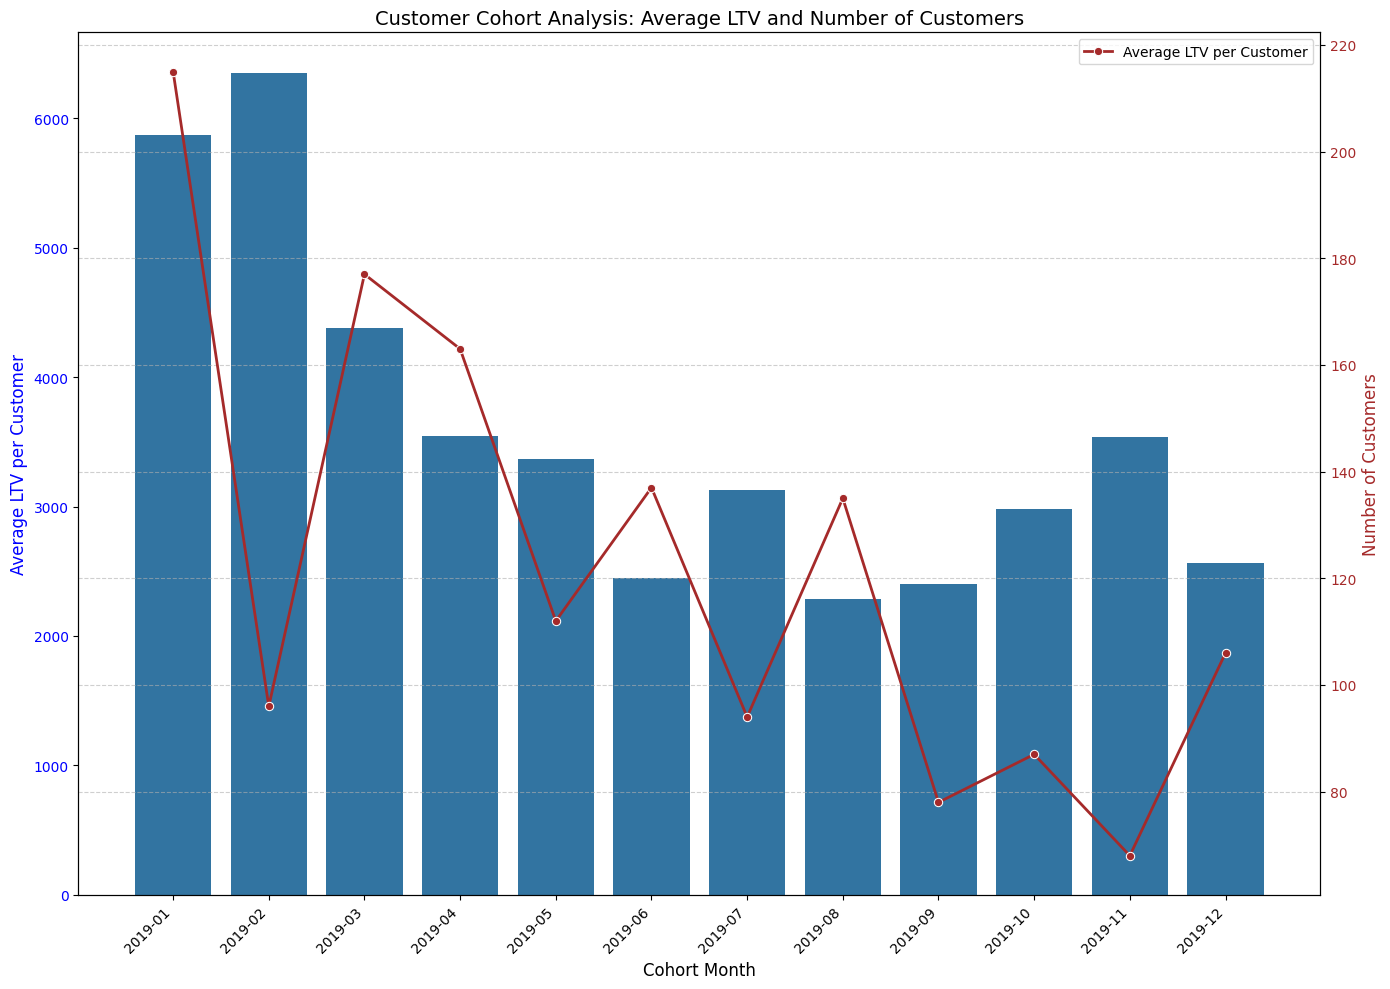

In [345]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure cohort_summary is sorted by Cohort_Month chronologically
# If 'Cohort_Month' is not already datetime, convert it for sorting
if not pd.api.types.is_datetime64_any_dtype(cohort_summary['Cohort_Month']):
    cohort_summary['Cohort_Month_DT'] = pd.to_datetime(cohort_summary['Cohort_Month'])
else:
    cohort_summary['Cohort_Month_DT'] = cohort_summary['Cohort_Month']

cohort_summary_sorted = cohort_summary.sort_values(by='Cohort_Month_DT').reset_index(drop=True)

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(14, 10)) # Increased figure height here

# Plot Avg_LTV_per_Customer as bars on ax1
# Using a single blue color ('#1f77b4') from the default matplotlib/seaborn categorical palette for bars
sns.barplot(x='Cohort_Month', y='Avg_LTV_per_Customer', data=cohort_summary_sorted, color='#1f77b4', ax=ax1, legend=False)
ax1.set_xlabel('Cohort Month', fontsize=12)
ax1.set_ylabel('Average LTV per Customer', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Customer Cohort Analysis: Average LTV and Number of Customers', fontsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Create a second y-axis to plot the number of customers
ax2 = ax1.twinx()
sns.lineplot(x='Cohort_Month', y='Customers', data=cohort_summary_sorted, color='brown', marker='o', linewidth=2, ax=ax2, label='Number of Customers')
ax2.set_ylabel('Number of Customers', color='brown', fontsize=12)
ax2.tick_params(axis='y', labelcolor='brown')

# Add legends for both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, ['Average LTV per Customer'] + labels2, loc='upper right') # Changed loc to 'upper right'

plt.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()


This visualization combines:

Bar chart → Number of customers acquired per cohort

Line chart → Average LTV per customer for that cohort

**Early-Year Cohorts (Jan-Mar)**

Higher Average LTV per customer

Moderate cohort sizes

Indicates strong long-term engagement and repeat purchases

**Interpretation:**
Customers acquired early in the year tend to stay longer and spend more over time, suggesting these cohorts represent higher-quality acquisitions.

**Mid-Year Cohorts (Apr–Jul)**

Stable customer acquisition volume

Moderate but declining Avg LTV

**Interpretation:**
These cohorts indicate scalable growth, but with slightly reduced per-customer value, possibly due to broader targeting or promotional acquisition.

**Late-Year Cohorts (Aug-Dec)**

In some months, relatively high acquisition volume

Lower observed Avg LTV

**Interpretation:**
Lower LTV here is primarily driven by shorter customer lifespan, not weaker purchasing behavior. These customers have simply had less time to generate lifetime value.

**Business Insight**

Cohort-level LTV varies meaningfully by acquisition period, with early-year cohorts generating significantly higher long-term value per customer. This demonstrates that acquisition timing and customer retention are more important drivers of lifetime value than raw acquisition volume alone.

**Recommendations**
Customer lifetime value varies significantly by acquisition cohort, with early-year cohorts delivering higher long-term value due to stronger retention. This highlights the importance of focusing acquisition strategies on customer quality and early engagement rather than short-term volume.”

9)Identify seasonal trends in sales by category and location. How can the company prepare for peak and off-peak seasons to maximize revenue?

Seasonality plays a critical role in e-commerce performance, influencing customer demand, product popularity, and regional buying behavior. Understanding how sales vary across product categories and customer locations over time enables the business to:

Anticipate peak and off-peak demand

Optimize inventory planning and supply chain readiness

Align marketing campaigns with seasonal demand patterns

Apply location-specific strategies instead of a one-size-fits-all approach

This analysis combines time, product category, and geographic location to uncover actionable seasonal insights.

In [346]:
category_monthly_revenue = sales_data.groupby(['Product_Category', 'Transaction_Month'])['Order_Value'].sum().reset_index()
category_monthly_revenue = category_monthly_revenue.rename(columns={'Order_Value': 'Monthly_Revenue'})
category_monthly_revenue.head()

,Product_Category,Transaction_Month,Monthly_Revenue
0,Accessories,2019-01,51.57
1,Accessories,2019-03,59.99
2,Accessories,2019-04,166.96
3,Accessories,2019-05,141.14
4,Accessories,2019-06,207.73


In [347]:
category_total_revenue = category_monthly_revenue.groupby(['Product_Category'])['Monthly_Revenue'].sum().reset_index()
category_total_revenue.head()

,Product_Category,Monthly_Revenue
0,Accessories,7295.88
1,Android,711.03
2,Apparel,591145.80
3,Backpacks,8772.69
4,Bags,151314.43


In [348]:
category_total_revenue.sort_values(by='Monthly_Revenue', ascending=False, inplace=True)
top_performing_categories = category_total_revenue.head(5)
top_performing_categories

,Product_Category,Monthly_Revenue
16,Nest-USA,2554202.39
2,Apparel,591145.80
14,Nest,518193.50
18,Office,276794.40
6,Drinkware,200707.83


In [349]:
selected_categories = ['Nest-USA', 'Apparel', 'Nest', 'Office', 'Drinkware']
filtered_category_monthly_revenue = category_monthly_revenue[category_monthly_revenue['Product_Category'].isin(selected_categories)]
filtered_category_monthly_revenue.head()

,Product_Category,Transaction_Month,Monthly_Revenue
19,Apparel,2019-01,38300.87
20,Apparel,2019-02,37990.09
21,Apparel,2019-03,59059.02
22,Apparel,2019-04,88138.14
23,Apparel,2019-05,58850.90


/tmp/ipython-input-2454747207.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_category_monthly_revenue['Transaction_Month_DT'] = pd.to_datetime(filtered_category_monthly_revenue['Transaction_Month'])


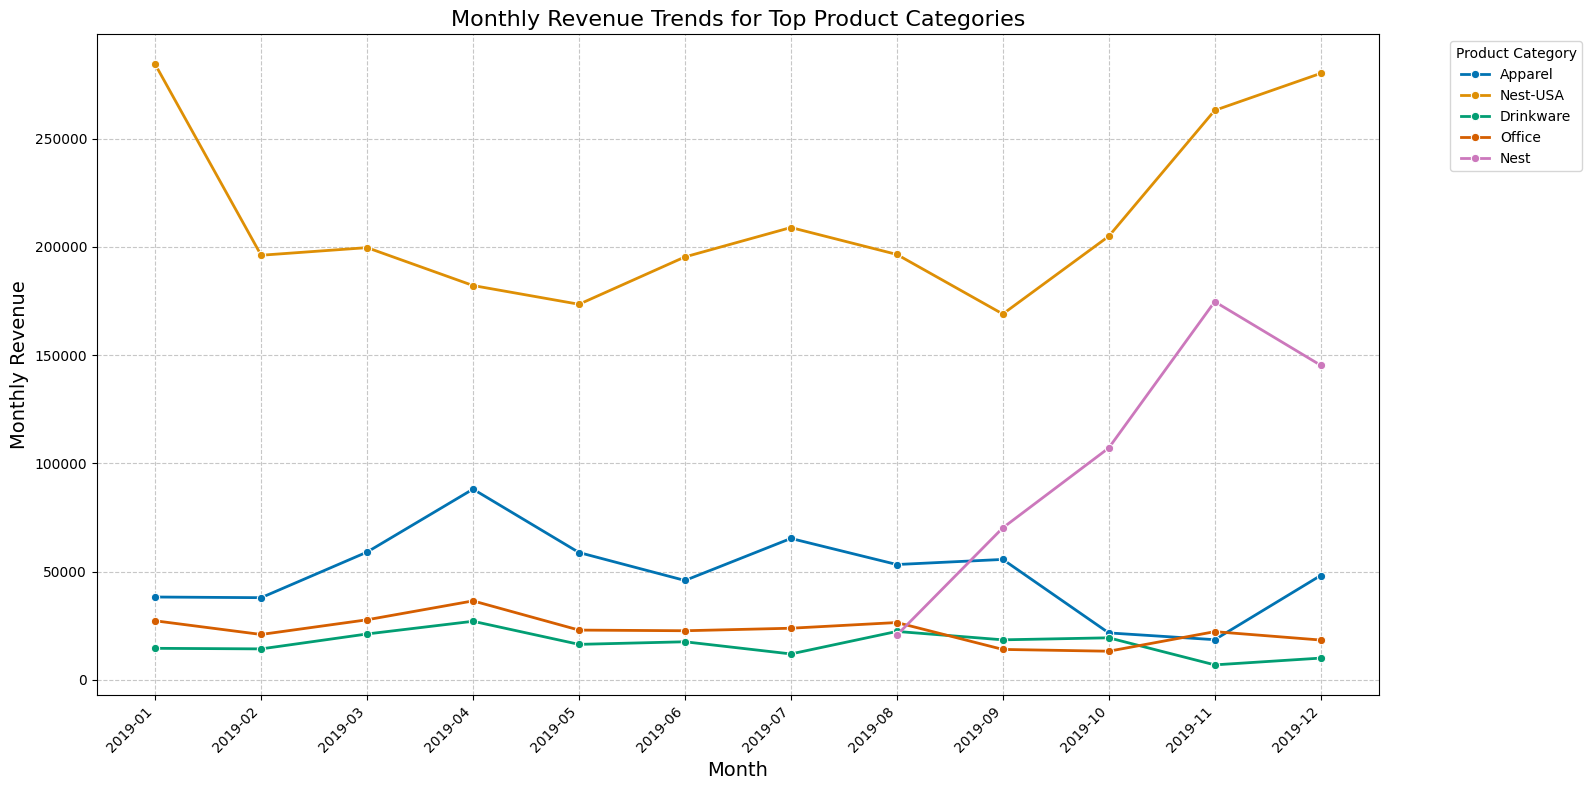

In [350]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Transaction_Month' is in datetime format for correct sorting
filtered_category_monthly_revenue['Transaction_Month_DT'] = pd.to_datetime(filtered_category_monthly_revenue['Transaction_Month'])

# Sort the DataFrame chronologically
filtered_category_monthly_revenue_sorted = filtered_category_monthly_revenue.sort_values(by='Transaction_Month_DT')

plt.figure(figsize=(16, 8))
sns.lineplot(
    x='Transaction_Month',
    y='Monthly_Revenue',
    hue='Product_Category',
    data=filtered_category_monthly_revenue_sorted,
    marker='o',
    linewidth=2,
    palette='colorblind' # Using a colorblind-friendly palette
)

plt.title('Monthly Revenue Trends for Top Product Categories', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Monthly Revenue', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Summary:**

Top-performing product categories display strong seasonal behavior, particularly during Q4. Smart home products (Nest categories) show significant holiday-driven demand, while Apparel and Office products exhibit seasonal peaks aligned with gifting and workplace purchase cycles. This suggests that category-level demand is heavily influenced by seasonal use cases and promotional timing.

In [351]:
unique_categories = category_monthly_revenue['Product_Category'].unique()
print(unique_categories)

['Accessories' 'Android' 'Apparel' 'Backpacks' 'Bags' 'Bottles'
 'Drinkware' 'Fun' 'Gift Cards' 'Google' 'Headgear' 'Housewares'
 'Lifestyle' 'More Bags' 'Nest' 'Nest-Canada' 'Nest-USA'
 'Notebooks & Journals' 'Office' 'Waze']


In [352]:
customers_data

,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49
...,...,...,...,...
1463,14438,F,New York,41
1464,12956,F,Chicago,48
1465,15781,M,New Jersey,19
1466,14410,F,New York,45


In [353]:
sales_data = pd.merge(sales_data, customers_data[['CustomerID', 'Location']], on='CustomerID', how='left')
sales_data.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Month,Order_Value,Cohort_Month,Revenue_Label,Activity_Month,Month_Offset,Location
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01,153.71,2019-01-01,New Customer Revenue,2019-01-01,0,Chicago
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,2019-01,153.71,2019-01-01,New Customer Revenue,2019-01-01,0,Chicago
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,2019-01,2.05,2019-01-01,New Customer Revenue,2019-01-01,0,Chicago
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,2019-01,87.65,2019-01-01,New Customer Revenue,2019-01-01,0,Chicago
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,2019-01,16.50,2019-01-01,New Customer Revenue,2019-01-01,0,Chicago


/tmp/ipython-input-3805399062.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_category_location_monthly_revenue['Transaction_Month_DT'] = pd.to_datetime(filtered_category_location_monthly_revenue['Transaction_Month'])


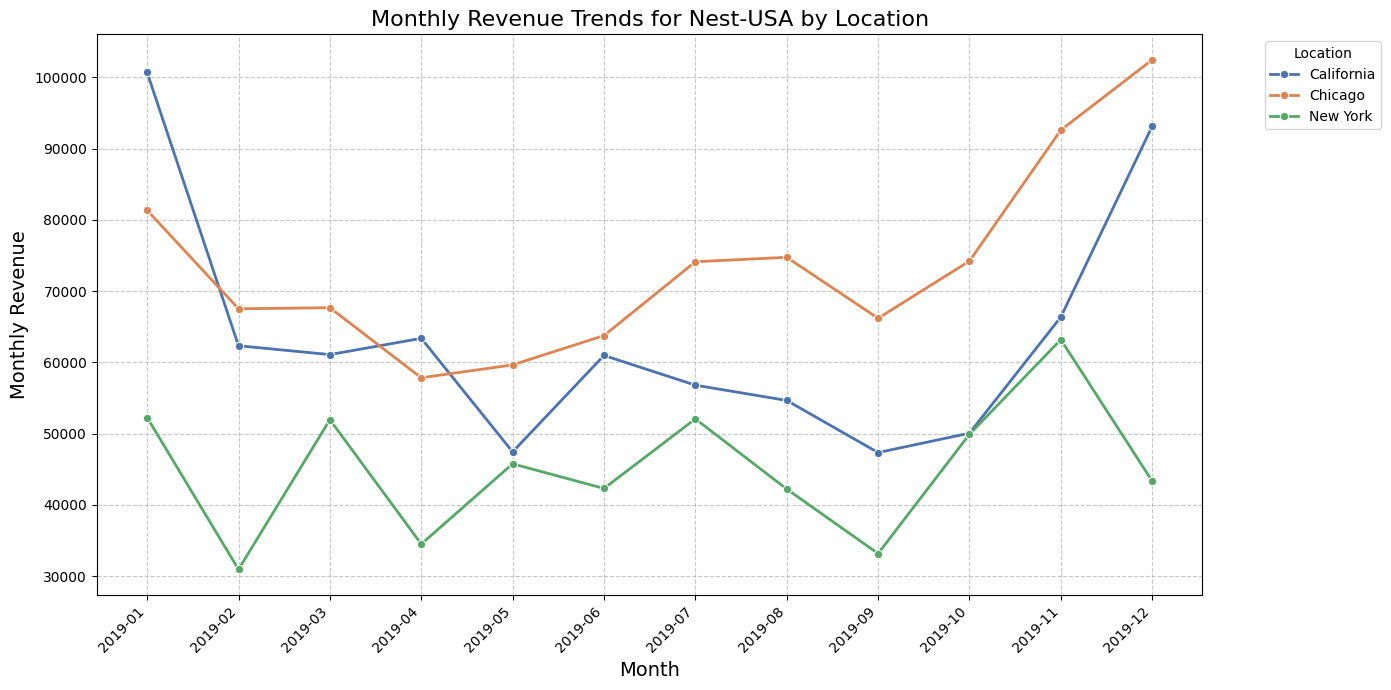

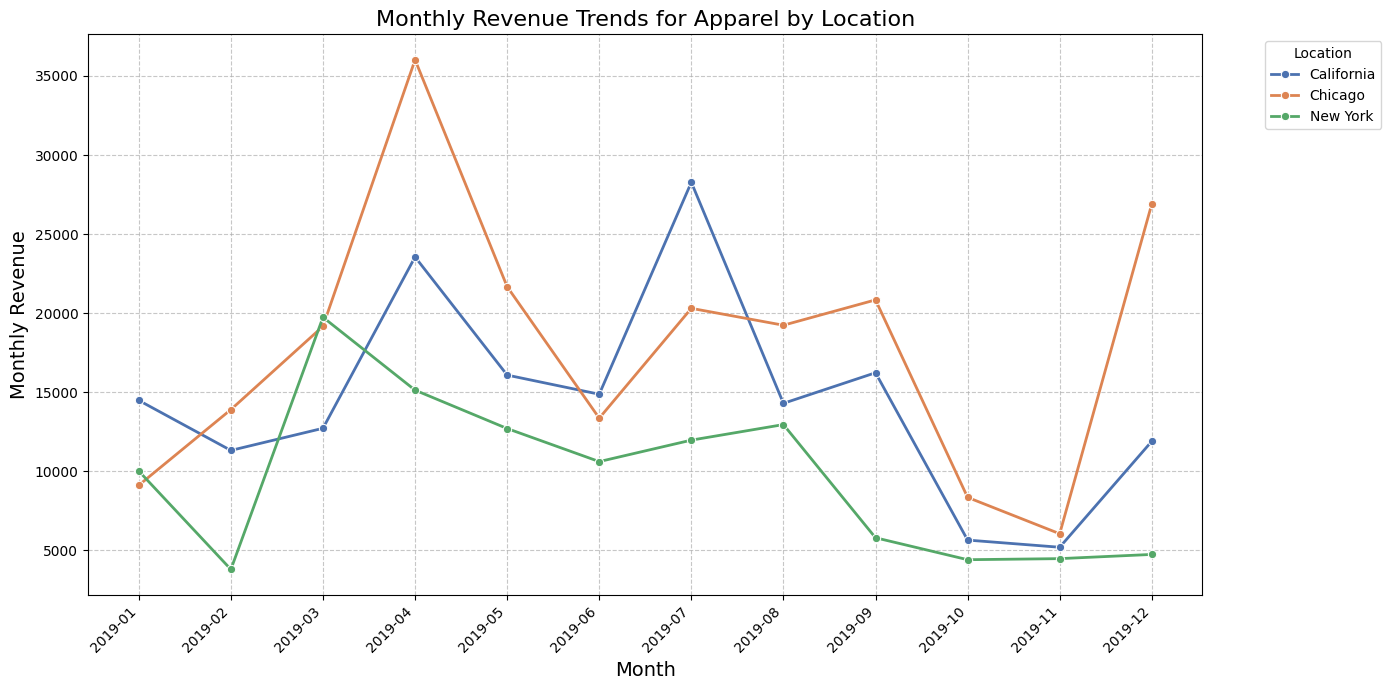

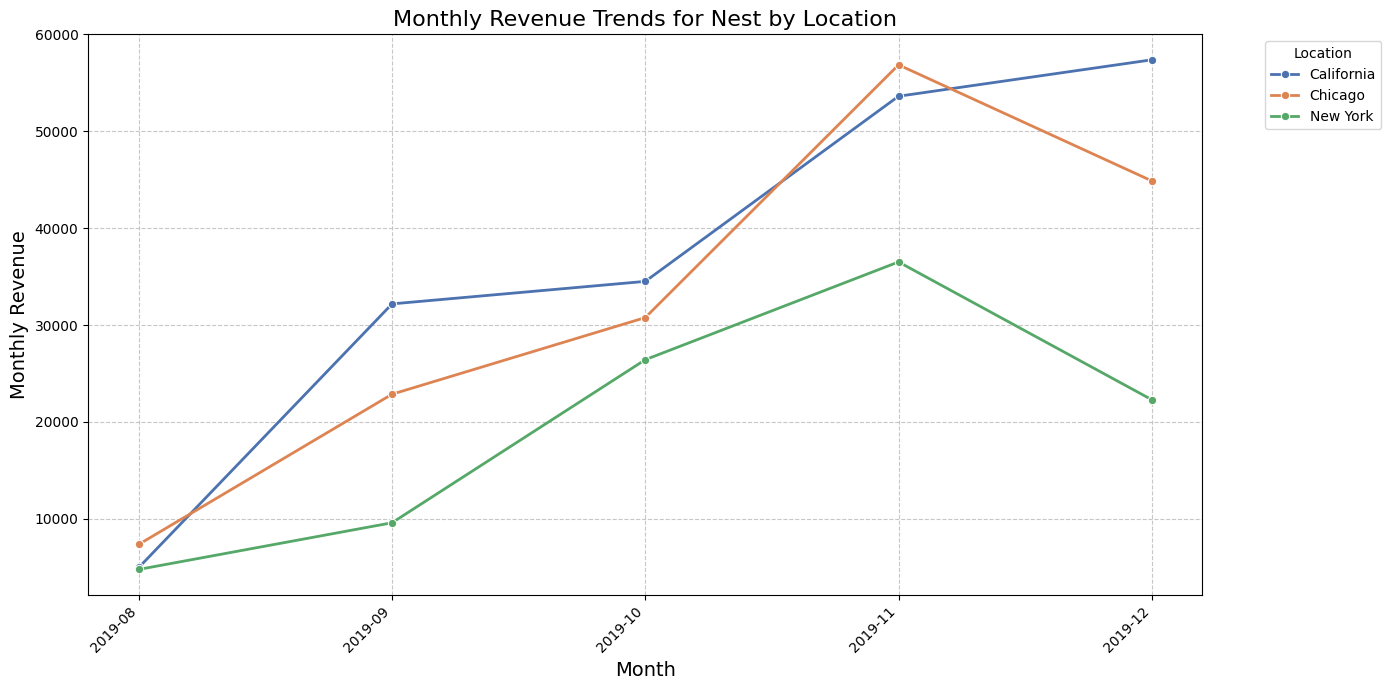

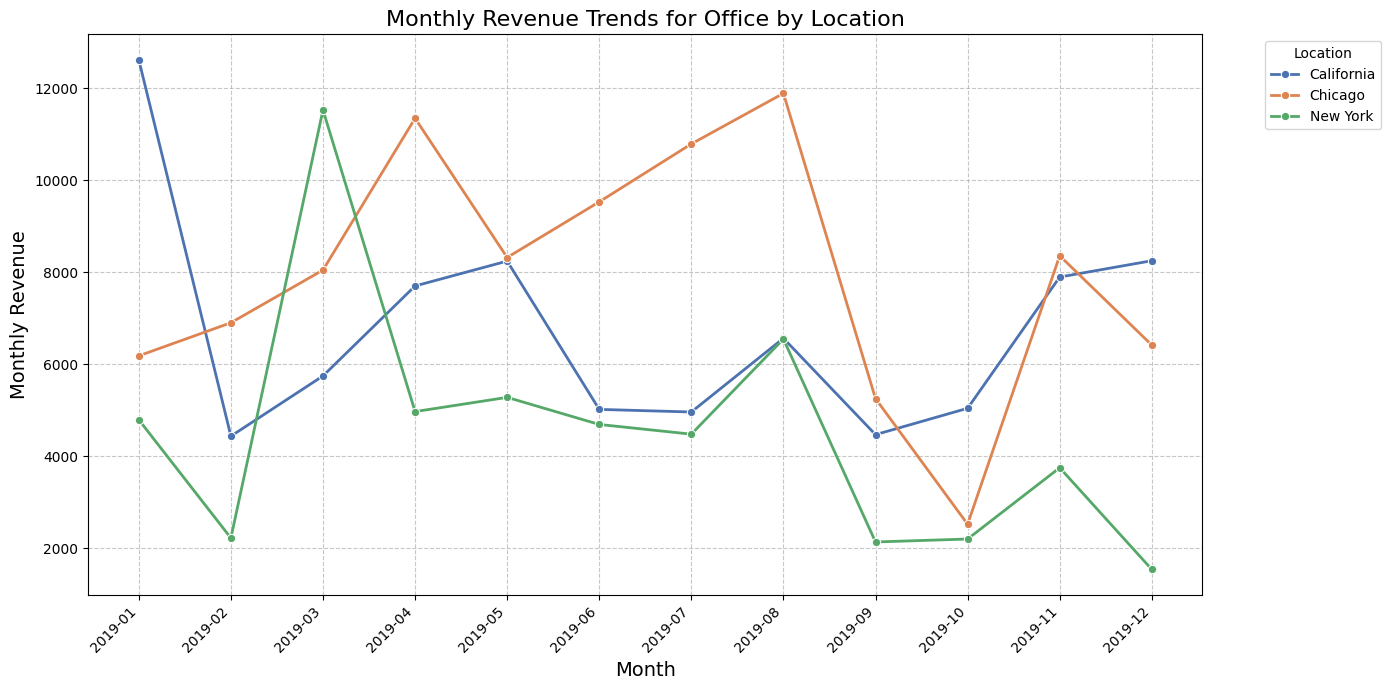

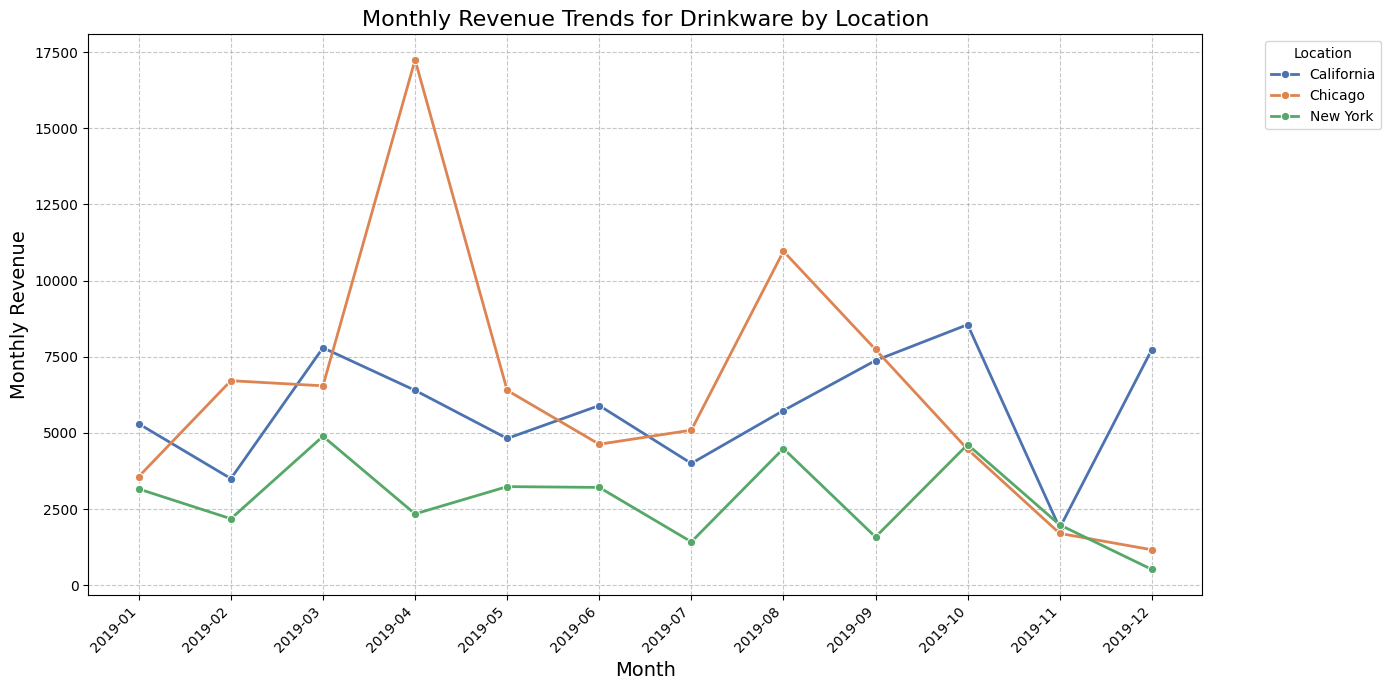

In [354]:
category_location_monthly_revenue = sales_data.groupby(['Product_Category', 'Location', 'Transaction_Month'])['Order_Value'].sum().reset_index()
category_location_monthly_revenue = category_location_monthly_revenue.rename(columns={'Order_Value': 'Monthly_Revenue'})

# Identify the top 5 performing categories overall for consistent analysis
top_5_overall_categories = sales_data.groupby('Product_Category')['Order_Value'].sum().nlargest(5).index

# Filter the data to include only the top 5 overall performing categories
filtered_category_location_monthly_revenue = category_location_monthly_revenue[category_location_monthly_revenue['Product_Category'].isin(top_5_overall_categories)]

# Prepare for chronological plotting
filtered_category_location_monthly_revenue['Transaction_Month_DT'] = pd.to_datetime(filtered_category_location_monthly_revenue['Transaction_Month'])
filtered_category_location_monthly_revenue_sorted = filtered_category_location_monthly_revenue.sort_values(by=['Product_Category', 'Location', 'Transaction_Month_DT'])

# Filter by specified locations
top_3_locations = ['Chicago', 'California', 'New York']
filtered_category_location_monthly_revenue_sorted = filtered_category_location_monthly_revenue_sorted[filtered_category_location_monthly_revenue_sorted['Location'].isin(top_3_locations)]

# Plotting for each top category across locations
for category in top_5_overall_categories:
    plt.figure(figsize=(14, 7))
    subset_data = filtered_category_location_monthly_revenue_sorted[filtered_category_location_monthly_revenue_sorted['Product_Category'] == category]

    # Check if there is data for the current category after filtering by location
    if not subset_data.empty:
        sns.lineplot(
            x='Transaction_Month',
            y='Monthly_Revenue',
            hue='Location',
            data=subset_data,
            marker='o',
            linewidth=2,
            palette='deep'
        )

        plt.title(f'Monthly Revenue Trends for {category} by Location', fontsize=16)
        plt.xlabel('Month', fontsize=14)
        plt.ylabel('Monthly Revenue', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

**Summary:**

A deeper drill-down across category and location reveals that regional seasonality is largely driven by category mix rather than uniform customer behavior. For example, Chicago’s strong performance is amplified by high Nest and Apparel sales, while California’s volatility reflects sensitivity to specific category demand. This confirms that regional sales patterns are shaped by the interaction between product preference and seasonal demand.

**Business Recommendations**

**1. Inventory & Supply Chain Planning**

Increase inventory for high-demand categories (Nest, Apparel) ahead of Q4

Use historical seasonality to prevent stockouts in top locations

Maintain lean inventory for low-demand categories during off-peak months

**2. Seasonal Marketing Strategy**

Align major campaigns with category-specific peak seasons

Use holiday-driven promotions for Nest products

Promote Apparel and Office products earlier in the year

**3. Location-Specific Optimization**

Prioritize inventory and marketing spend in consistently strong markets (Chicago)

Use targeted, event-driven campaigns in volatile markets (California)

Focus on selective promotions rather than broad campaigns in lower-volume markets (New York)

**4. Off-Peak Revenue Stabilization**

Introduce bundles and cross-category promotions during slow months

Use personalized offers to stimulate demand outside peak seasons

Shift marketing objectives from volume to conversion efficiency in off-peak periods


Seasonal analysis by category and location shows that revenue peaks are driven by a combination of holiday demand and category-specific purchasing behavior, with significant variation across regions. By aligning inventory, marketing, and promotional strategies with these seasonal patterns, the business can maximize peak-season revenue while mitigating off-season slowdowns.

In [355]:
revenue_by_location = sales_data.groupby('Location')['Order_Value'].sum().reset_index()
revenue_by_location = revenue_by_location.rename(columns={'Order_Value': 'Total_Revenue'})
revenue_by_location.sort_values(by='Total_Revenue', ascending=False, inplace=True)

print(revenue_by_location)

        Location  Total_Revenue
1        Chicago     1625885.58
0     California     1442447.31
3       New York      937022.63
2     New Jersey      409666.86
4  Washington DC      255772.24


In [356]:
top_3_locations = ['Chicago', 'California', 'New York']
filtered_sales_data = sales_data[sales_data['Location'].isin(top_3_locations)]

monthly_revenue_by_location = filtered_sales_data.groupby(['Transaction_Month', 'Location'])['Order_Value'].sum().reset_index()
monthly_revenue_by_location = monthly_revenue_by_location.rename(columns={'Order_Value': 'Monthly_Revenue'})
monthly_revenue_by_location.head()

,Transaction_Month,Location,Monthly_Revenue
0,2019-01,California,150241.63
1,2019-01,Chicago,109911.74
2,2019-01,New York,78217.28
3,2019-02,California,89727.46
4,2019-02,Chicago,108031.09


Below I'm identifying the the top 3 locations with highest revenue to observe seasonality in those locations which we are seeing in the analysis above.

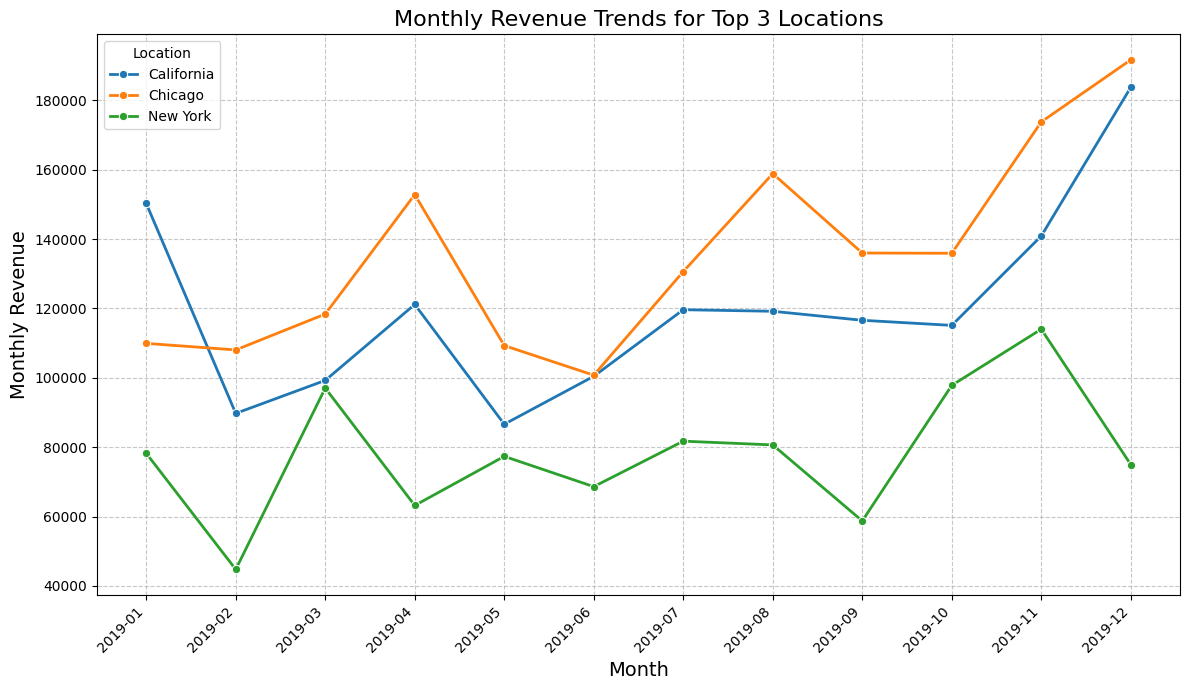

In [357]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Transaction_Month' is in datetime format for correct chronological sorting
monthly_revenue_by_location['Transaction_Month_DT'] = pd.to_datetime(monthly_revenue_by_location['Transaction_Month'])
monthly_revenue_by_location_sorted = monthly_revenue_by_location.sort_values(by='Transaction_Month_DT').drop(columns='Transaction_Month_DT')

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=monthly_revenue_by_location_sorted,
    x='Transaction_Month',
    y='Monthly_Revenue',
    hue='Location',
    marker='o', # Add markers to points
    linewidth=2
)

plt.title('Monthly Revenue Trends for Top 3 Locations', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Monthly Revenue', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Location')
plt.tight_layout()
plt.show()

10) Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?




Understanding daily sales patterns helps the business optimize campaign timing, staffing, and promotional strategies. Rather than treating each calendar date independently, analyzing performance by day of the week reveals consistent behavioral patterns in customer purchasing intent. These insights enable the company to smooth demand, improve operational efficiency, and increase revenue on traditionally slower days.

In [358]:
sales_data['Day_of_Week'] = sales_data['Transaction_Date'].dt.day_name()

daily_summary = sales_data.groupby('Day_of_Week').agg(
    Total_Daily_Revenue=('Order_Value', 'sum'),
    Total_Transactions=('Transaction_ID', 'nunique')
).reset_index()

# Define the order of days for better visualization
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_summary['Day_of_Week'] = pd.Categorical(daily_summary['Day_of_Week'], categories=day_order, ordered=True)

daily_summary = daily_summary.sort_values('Day_of_Week')
display(daily_summary)

,Day_of_Week,Total_Daily_Revenue,Total_Transactions
1,Monday,365626.90,2130
5,Tuesday,396819.65,2315
6,Wednesday,826622.00,4378
4,Thursday,840433.85,4278
0,Friday,872004.86,4233
2,Saturday,673068.03,3872
3,Sunday,696219.33,3855


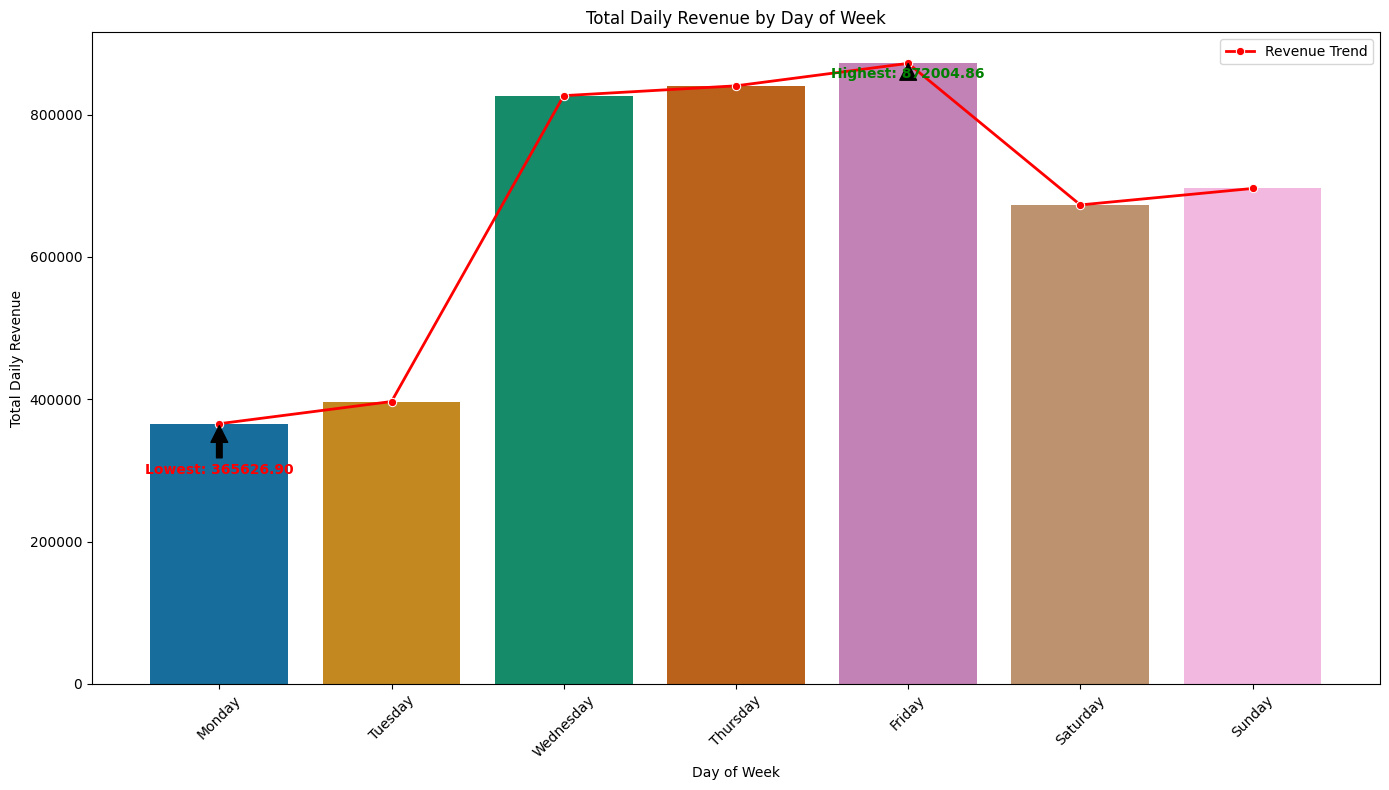

In [359]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure daily_summary is available from previous steps
# If not, recreate it:
# sales_data['Day_of_Week'] = sales_data['Transaction_Date'].dt.day_name()
# daily_summary = sales_data.groupby('Day_of_Week').agg(
#     Total_Daily_Revenue=('Order_Value', 'sum'),
#     Total_Transactions=('Transaction_ID', 'nunique')
# ).reset_index()
# day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# daily_summary['Day_of_Week'] = pd.Categorical(daily_summary['Day_of_Week'], categories=day_order, ordered=True)
# daily_summary = daily_summary.sort_values('Day_of_Week')

plt.figure(figsize=(14, 8)) # Increased figure size
sns.barplot(x='Day_of_Week', y='Total_Daily_Revenue', data=daily_summary, palette='colorblind', hue='Day_of_Week', legend=False) # Changed palette to 'colorblind'
sns.lineplot(x='Day_of_Week', y='Total_Daily_Revenue', data=daily_summary, color='red', marker='o', linewidth=2, label='Revenue Trend') # Added trend line

# Annotate highest and lowest days
highest_revenue_day = daily_summary.loc[daily_summary['Total_Daily_Revenue'].idxmax()]
lowest_revenue_day = daily_summary.loc[daily_summary['Total_Daily_Revenue'].idxmin()]

plt.annotate(
    f'Highest: {highest_revenue_day['Total_Daily_Revenue']:.2f}',
    xy=(highest_revenue_day['Day_of_Week'], highest_revenue_day['Total_Daily_Revenue']),
    xytext=(highest_revenue_day['Day_of_Week'], highest_revenue_day['Total_Daily_Revenue'] - 20000), # Adjusted text position to be inside the bar
    arrowprops=dict(facecolor='black', shrink=0.05),
    ha='center',
    color='green',
    weight='bold'
)

plt.annotate(
    f'Lowest: {lowest_revenue_day['Total_Daily_Revenue']:.2f}',
    xy=(lowest_revenue_day['Day_of_Week'], lowest_revenue_day['Total_Daily_Revenue']),
    xytext=(lowest_revenue_day['Day_of_Week'], lowest_revenue_day['Total_Daily_Revenue'] - 70000), # Adjusted text position
    arrowprops=dict(facecolor='black', shrink=0.05),
    ha='center',
    color='red',
    weight='bold'
)

plt.title('Total Daily Revenue by Day of Week') # Removed loc='left' to revert to default center
plt.xlabel('Day of Week')
plt.ylabel('Total Daily Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

This visualization compares total revenue and number of transactions across each day of the week.

**High-Performing Days (Wednesday-Friday)**

Friday emerges as the strongest revenue-generating day.

Wednesday and Thursday also show consistently high revenue and transaction volume.

**Interpretation:**
Customer purchase intent increases as the week progresses, likely driven by paycheck cycles, planned purchases, and end-of-week shopping behavior.

**Low-Performing Days (Monday0-Tuesday)**

Monday and Tuesday consistently generate the lowest revenue and transaction counts.

**Interpretation:**
Early-week days reflect lower discretionary spending and reduced customer engagement, presenting clear opportunities for demand stimulation.

**Weekend Performance (Saturday-Sunday)**

Weekends show moderate revenue levels.

Performance is better than early weekdays but below mid-week peaks.

**Interpretation:**
Customers may browse more on weekends but convert less frequently compared to high-intent weekday shopping periods.

**Daily sales performance follows a predictable weekly cycle, with peak purchasing occurring mid-to-late week and demand softening at the start of the week.**

**Business Recommendations:**
1. Boost Low-Performing Days (Monday-Tuesday)

Introduce early-week flash sales or limited-time discounts.

Deploy targeted coupons for inactive or recently browsing customers.

Use email and push notifications to stimulate demand.

2. Retarget Weekend Browsers

Identify customers who browsed or abandoned carts over the weekend.

Retarget them on Monday with personalized offers or reminders.

3. Optimize Campaign Timing

Launch marketing campaigns on Tuesday or Wednesday to capture momentum ahead of peak days.

Reserve major product launches or promotions for mid-week exposure.

4. Improve Operational Efficiency

Allocate higher fulfillment capacity and support staffing toward Wednesday–Friday.

Use slower days for operational optimization, testing, or maintenance.

**Daily sales analysis shows that mid-week and end-week days drive the majority of revenue, while early-week days underperform—creating clear opportunities for targeted promotions and demand smoothing.**

**Conclusion**

This analysis demonstrates that long-term e-commerce growth is driven less by aggressive acquisition and more by strategic retention, customer value optimization, and seasonal alignment. By focusing on high-quality customers, strengthening early engagement, and tailoring strategies by time, category, and location, the business can improve customer lifetime value, marketing efficiency, and revenue stability.

In [361]:
# 1. Install the necessary conversion tools
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

# 2. Convert the notebook to PDF
# Replace 'Your_Notebook_Name.ipynb' with your actual file name
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Scaler AIML/Case Study: Ecommerce-Marketing & Sales/Ecommerce_casestudy.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
[NbConvertApp] Converting notebook /content/drive/MyDrive/Scaler AIML/Case Study: Ecommerce-Marketing & Sales/Ecommerce_casestudy.ipynb to pdf
[NbConvertApp] Support files will be in Ecommerce_casestudy_files/
[NbConvertApp] Making directory ./Ecommerce_casestudy_files
[NbConvertApp] Writing 283262 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertAp